## 1. Постановка задачи


В данном проекте вы решите настоящую бизнес-задачу в области маркетинга. Вам предстоит произвести сегментацию клиентов на основе их покупательской способности, частоты совершения заказов и срока давности последнего заказа, а также определить оптимальную стратегию взаимодействия с ними.
<center> <img src=https://salesupnow.ru/storage/app/media/pipeople.png align="right" width="300"/> </center>

Маркетинг — неотъемлемая часть любого бизнеса. Для повышения прибыли компании важно понимать своего клиента, его пожелания и предпочтения. С появлением электронной коммерции, или онлайн-продаж, стало намного проще собирать данные о клиентах, анализировать их, находить закономерности и реализовывать маркетинговые кампании.

Большинство интернет-магазинов используют инструменты веб-аналитики, чтобы отслеживать просмотры страниц, количество и поведение посетителей и коэффициент отказов. Но отчёта из Google Analytics или аналогичной системы может быть недостаточно для полного понимания того, как клиенты взаимодействуют с сайтом. Компаниям важно иметь возможность быстро и точно реагировать на перемены в поведении клиентов, создавая инструменты, которые обнаруживают эти изменения практически в режиме реального времени.

Машинное обучение помогает поисковой системе анализировать огромное количество данных о посетителях платформы, узнавать модели поведения профессиональных покупателей, определять категорию клиентов (например, лояльные/перспективные/новички/спящие/ушедшие) и выбирать правильную стратегию взаимодействия с ними.

Стоит также отметить, что компании, использующие машинное обучение на своих платформах электронной коммерции, могут постоянно повышать эффективность бизнес-процессов: настраивать товарную выборку персонально для каждого покупателя и предлагать выгодную цену в соответствии с бюджетом клиента и т. д. Эта задача относится к категории построения рекомендательных систем, речь о которых пойдёт в следующем разделе нашего курса.

Как правило, наборы данных для электронной коммерции являются частной собственностью и, следовательно, их трудно найти среди общедоступных данных. 

**Бизнес-задача:** произвести сегментацию существующих клиентов, проинтерпретировать эти сегменты и определить стратегию взаимодействия с ними.

**Техническая задача для вас как для специалиста в Data Science:** построить модель кластеризации клиентов на основе их покупательской способности, частоты заказов и срока давности последней покупки, определить профиль каждого из кластеров.

**Основные цели проекта:**
1. Произвести предобработку набора данных.
2. Провести разведывательный анализ данных и выявить основные закономерности.
3. Сформировать категории товаров и клиентов. 
4. Построить несколько моделей машинного обучения, решающих задачу кластеризации клиентов, определить количество кластеров и проинтерпретировать их.
5. Спроектировать процесс предсказания категории интересов клиента и протестировать вашу модель на новых клиентах.



## 2. Знакомство с данными. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn import mixture
from sklearn import manifold
from sklearn import pipeline
from sklearn import preprocessing
from sklearn import cluster
from sklearn import metrics
from sklearn import model_selection
from sklearn import decomposition
from sklearn import ensemble
import warnings 

from IPython.display import display, HTML

warnings.filterwarnings("ignore")

plt.rcParams["patch.force_edgecolor"] = True

Первым делом необходимо понять, с какими данными нам предстоит работать, и произвести базовую предобработку данных, переведя признаки в необходимые для дальнейшей работы форматы.


Для начала давайте познакомимся с нашими данными:

In [3]:
data = pd.read_csv(
    "customer_segmentation_project.csv",
    encoding="ISO-8859-1", 
    dtype={'CustomerID': str,'InvoiceID': str}
)
print('Data shape: {}'.format(data.shape))
data.head(5)

Data shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


Итак, у нас есть данные о более чем полумиллионе транзакций. Каждая из них описывается следующими признаками:

* InvoiceNo — номер счёта-фактуры (уникальный номинальный шестизначный номер, присваиваемый каждой транзакции; буква "C" в начале кода указывает на отмену транзакции);
* Stock Code — код товара (уникальное пятизначное целое число, присваиваемое каждому отдельному товару);
* Description — название товара;
* Quantity — количество каждого товара за транзакцию; 
* InvoiceDate — дата и время выставления счёта/проведения транзакции;
* UnitPrice — цена за единицу товара в фунтах стерлингов;
* CustomerID — идентификатор клиента (уникальный пятизначный номер, однозначно присваиваемый каждому клиенту);
* Country — название страны, в которой проживает клиент.

Проведём анализ структуры таблицы.


### Задание 2.1
Сколько столбцов в данных кодируются числовыми типами (int/float)?

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  object 
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


### Задание 2.2
Выберите столбцы, в которых есть хотя бы один пропуск:
* InvoiceNo
* StockCode
* Description
* CustomerID
* Country 

In [5]:
# Description
# CustomerID

### Задание 2.3
Судя по описанию задачи, нам должны были предоставить данные за годовой период — проверим, так ли это.

Преобразуйте столбец InvoiceDate в формат datetime.
Укажите, за какой промежуток времени представлены данные:

* 2010-12-01 to 2011-12-09
* 2011-12-01 to 2012-12-09
* 2010-01-01 to 2011-01-09
* 2020-12-01 to 2021-12-09


In [6]:
# Преобразуем столбец InvoiceDate в формат datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'], format='%m/%d/%Y %H:%M')

# Проверяем минимальную и максимальную даты
min_date = data['InvoiceDate'].min()
max_date = data['InvoiceDate'].max()

print(f"Минимальная дата: {min_date}")
print(f"Максимальная дата: {max_date}")
print(f"Период данных: {min_date.date()} to {max_date.date()}")

Минимальная дата: 2010-12-01 08:26:00
Максимальная дата: 2011-12-09 12:50:00
Период данных: 2010-12-01 to 2011-12-09


### Задание 2.4

1) Каково максимальное количество товаров в заказе (Quantity)? Ответ приведите в виде целого числа.

2) Каково минимальное количество товаров в заказе (Quantity)? Ответ приведите в виде целого числа.

3) Сколько, согласно данным, стоит самый дешёвый товар (за исключением товаров с отрицательной стоимостью)?

In [7]:


# 1. Максимальное количество товаров в заказе
max_quantity = data['Quantity'].max()
print(f"1. Максимальное количество товаров в заказе (Quantity): {max_quantity}")

# 2. Минимальное количество товаров в заказе
min_quantity = data['Quantity'].min()
print(f"2. Минимальное количество товаров в заказе (Quantity): {min_quantity}")

# 3. Самый дешёвый товар (за исключением отрицательной стоимости)
min_positive_price = data[data['UnitPrice'] > 0]['UnitPrice'].min()
print(f"3. Самый дешёвый товар (UnitPrice > 0): {min_positive_price}")

# Дополнительная информация для проверки
print("\n=== Дополнительная проверка ===")
print(f"Описательные статистики Quantity:\n{data['Quantity'].describe()}")
print(f"\nОписательные статистики UnitPrice:\n{data['UnitPrice'].describe()}")
print(f"\nМинимальная цена (все значения): {data['UnitPrice'].min()}")
print(f"Количество записей с отрицательной ценой: {(data['UnitPrice'] < 0).sum()}")
print(f"Количество записей с нулевой ценой: {(data['UnitPrice'] == 0).sum()}")

1. Максимальное количество товаров в заказе (Quantity): 80995
2. Минимальное количество товаров в заказе (Quantity): -80995
3. Самый дешёвый товар (UnitPrice > 0): 0.001

=== Дополнительная проверка ===
Описательные статистики Quantity:
count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

Описательные статистики UnitPrice:
count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

Минимальная цена (все значения): -11062.06
Количество записей с отрицательной ценой: 2
Количество записей с нулевой ценой: 2515


### Задание 2.5
1) Сколько уникальных клиентов покупали товары за период выгрузки датасета?

2) Сколько уникальных стран содержится в столбце Country (исключая специальный код 'Unspecified', обозначающий неопределенную страну)?

3) Укажите идентификатор самого популярного товара (StockCode):
* 85123A
* 64812
* 51242
* 24151B


In [8]:


# 1. Количество уникальных клиентов
unique_customers = data['CustomerID'].nunique()
print(f"1. Уникальных клиентов: {unique_customers}")

# 2. Количество уникальных стран (исключая 'Unspecified')
countries = data['Country'].unique()
print(f"\nВсе уникальные страны: {sorted(countries)}")
unique_countries = len([c for c in countries if c != 'Unspecified'])
print(f"2. Уникальных стран (без 'Unspecified'): {unique_countries}")

# 3. Самый популярный товар
print("\nТоп-10 самых популярных товаров (по количеству транзакций):")
top_stock = data['StockCode'].value_counts().head(10)
print(top_stock)

most_popular = data['StockCode'].value_counts().idxmax()
print(f"\nСамый популярный товар: {most_popular}")
print(f"Количество транзакций с ним: {data['StockCode'].value_counts().max()}")

1. Уникальных клиентов: 4372

Все уникальные страны: ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'Channel Islands', 'Cyprus', 'Czech Republic', 'Denmark', 'EIRE', 'European Community', 'Finland', 'France', 'Germany', 'Greece', 'Hong Kong', 'Iceland', 'Israel', 'Italy', 'Japan', 'Lebanon', 'Lithuania', 'Malta', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'RSA', 'Saudi Arabia', 'Singapore', 'Spain', 'Sweden', 'Switzerland', 'USA', 'United Arab Emirates', 'United Kingdom', 'Unspecified']
2. Уникальных стран (без 'Unspecified'): 37

Топ-10 самых популярных товаров (по количеству транзакций):
StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
84879     1502
22720     1477
22197     1476
21212     1385
20727     1350
Name: count, dtype: int64

Самый популярный товар: 85123A
Количество транзакций с ним: 2313


## 3. Предобработка и очистка данных

На этом этапе нам предстоит подготовить наш датасет для дальнейшего моделирования, произведя очистку данных.


### Задание 3.1
Начнем с пропусков. 

1) Сколько всего в таблице пропущенных значений?

2) Пропуски в столбце с идентификатором клиента и описанием товара свидетельствуют о некорректных/незавершённых транзакциях.

Удалите строки, содержащие пропуски в этих столбцах. Сколько строк осталось в таблице?



In [9]:
# 1. Подсчёт общего количества пропущенных значений в таблице
total_missing = data.isnull().sum().sum()
print(f"1. Общее количество пропущенных значений: {total_missing}")

# Посмотрим распределение пропусков по столбцам
print("\nПропуски по столбцам:")
print(data.isnull().sum())

# 2. Удаляем строки с пропусками в столбцах CustomerID и Description
data_cleaned = data.dropna(subset=['CustomerID', 'Description'])
print(f"\n2. Количество строк после удаления пропусков: {data_cleaned.shape[0]}")
print(f"   Было строк: {data.shape[0]}")
print(f"   Удалено строк: {data.shape[0] - data_cleaned.shape[0]}")

1. Общее количество пропущенных значений: 136534

Пропуски по столбцам:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

2. Количество строк после удаления пропусков: 406829
   Было строк: 541909
   Удалено строк: 135080


### Задание 3.2
Следом за пропусками проверим наличие дубликатов.

1) Сколько в таблице полностью дублирующихся записей?

2) Удалите дубликаты из таблицы. Сколько строк осталось?



In [10]:
# количество полностью дублирующихся записей

duplicates_count = data.duplicated().sum()
print(f"1. Количество полностью дублирующихся записей: {duplicates_count}")

# 2. Удаляем дубликаты из таблицы
data = data.drop_duplicates()
print(f"2. Количество строк после удаления дубликатов: {data.shape[0]}")
print(f"   (Было: {data.shape[0] + duplicates_count}, удалено: {duplicates_count})")

1. Количество полностью дублирующихся записей: 5268
2. Количество строк после удаления дубликатов: 536641
   (Было: 541909, удалено: 5268)


Ранее мы заметили, что в столбце с количеством товара есть отрицательные значения. Давайте разберемся, откуда они взялись. Выведем первые 5 строк таблицы, в которой столбец Quantity меньше 0.

In [11]:
negative_quantity = data[(data['Quantity']<0)]
print('Count of entries with a negative number: {}'.format(negative_quantity.shape[0]))
negative_quantity.head()

Count of entries with a negative number: 10587


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom


### Задание 3.3
Давайте проверим, что все записи из таблицы с отрицательным количеством товара действительно являются возвратными транзакциями. Если транзакция не является возвратом, но содержит отрицательное количество товара, это будет поводом считать её выбросом.

Сколько транзакций из таблицы negative_quantity не содержат в номере заказа признак возврата?

In [12]:
# Возвращаем индекс в столбцы
negative_quantity_reset = negative_quantity.reset_index()

# Теперь InvoiceNo — обычный столбец, приводим к строке
negative_quantity_reset['InvoiceNo'] = negative_quantity_reset['InvoiceNo'].astype(str)

# Проверяем, какие НЕ начинаются с 'C'
non_return_transactions = negative_quantity_reset[
    ~negative_quantity_reset['InvoiceNo'].str.startswith('C')
]

print(f"Всего транзакций с отрицательным количеством: {negative_quantity.shape[0]}")
print(f"Транзакций БЕЗ признака возврата: {non_return_transactions.shape[0]}")

Всего транзакций с отрицательным количеством: 10587
Транзакций БЕЗ признака возврата: 1336


Давайте подробнее разберёмся с возвратами. Сейчас на каждый уникальный товар заведена отдельная строка в таблице — это мешает определить общее количество возвратов.

Чтобы подсчитать число возвратов, сначала необходимо определить, сколько уникальных товаров указано в транзакции (корзине/basket) для каждой уникальной пары «клиент-заказ»:


In [13]:
temp = data.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)['InvoiceDate'].count()
nb_products_per_basket = temp.rename(columns = {'InvoiceDate':'Number of products'})
nb_products_per_basket.head()

,CustomerID,InvoiceNo,Number of products
0,12346,541431,1
1,12346,C541433,1
2,12347,537626,31
3,12347,542237,29
4,12347,549222,24


### Задание 3.4
Добавьте во вспомогательную таблицу nb_products_per_basket признак отмены заказа (order_canceled): он равен 1, если транзакция является возвратом, и 0 — в противном случае.

Сколько процентов заказов в таблице являются возвратами? Ответ приведите в виде целого числа.


In [14]:
# Добавляем признак отмены заказа
# Заказ является возвратом, если индекс (InvoiceNo) начинается с 'C'
nb_products_per_basket['order_canceled'] = (
    nb_products_per_basket.index
    .astype(str)
    .str.startswith('C')
    .astype(int)
)

# Проверяем результат
print("Первые строки таблицы с новым признаком:")
print(nb_products_per_basket.head(10))

# Считаем процент возвратов
total_orders = len(nb_products_per_basket)
canceled_orders = (nb_products_per_basket['order_canceled'] == 1).sum()
canceled_pct = canceled_orders / total_orders * 100

print(f"\nВсего заказов: {total_orders}")
print(f"Заказов-возвратов: {canceled_orders}")
print(f"Процент возвратов: {canceled_pct:.2f}%")
print(f"Округлённо: {round(canceled_pct)}%")

Первые строки таблицы с новым признаком:
  CustomerID InvoiceNo  Number of products  order_canceled
0      12346    541431                   1               0
1      12346   C541433                   1               0
2      12347    537626                  31               0
3      12347    542237                  29               0
4      12347    549222                  24               0
5      12347    556201                  18               0
6      12347    562032                  22               0
7      12347    573511                  47               0
8      12347    581180                  11               0
9      12348    539318                  17               0

Всего заказов: 22190
Заказов-возвратов: 0
Процент возвратов: 0.00%
Округлённо: 0%


Давайте поближе взглянем на отмененные заказы:


In [15]:
nb_products_per_basket[nb_products_per_basket['order_canceled']==1].head()

,CustomerID,InvoiceNo,Number of products,order_canceled


Найдем в таблице со всеми транзакциями записи принадлежащие клиенту с идентификатором 12346:


In [16]:
data[data['CustomerID'] == '12346']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346,United Kingdom


Итак, вот пример пары «заказ-отмена». Обратите внимание на столбцы StockCode, UnitPrice, CustomerID и Quantity, сравните их для двух транзакций. 

### Задание 3.5
Выдвигаем гипотезу: для каждой отменённой транзакции в базе данных (таблица data) существует её аналог с тем же кодом товара, идентификатором клиента и противоположным значением количества товара.

* Верна ли гипотеза?
* Да, верна



In [17]:
# Создаём таблицу возвратов и таблицу положительных транзакций
returns = data[data['Quantity'] < 0].copy()
returns['abs_quantity'] = -returns['Quantity']  # модуль количества

purchases = data[data['Quantity'] > 0].copy()

# Пытаемся найти пары через merge
merged = returns.merge(
    purchases,
    left_on=['CustomerID', 'StockCode', 'abs_quantity'],
    right_on=['CustomerID', 'StockCode', 'Quantity'],
    how='left',
    suffixes=('_return', '_purchase'),
    indicator=True
)

# Считаем, сколько возвратов не нашли пару
unmatched = merged[merged['_merge'] == 'left_only']
print(f"Всего возвратов: {len(returns)}")
print(f"Возвратов с парой: {len(merged[merged['_merge'] == 'both'])}")
print(f"Возвратов БЕЗ пары: {len(unmatched)}")
print(f"\nГипотеза верна: {len(unmatched) == 0}")

# Контр-пример: клиент 14527
print("\nКонтр-пример (клиент 14527):")
print(data[data['CustomerID'] == '14527'].head())

Всего возвратов: 10587
Возвратов с парой: 12495
Возвратов БЕЗ пары: 6893

Гипотеза верна: False

Контр-пример (клиент 14527):
     InvoiceNo StockCode                        Description  Quantity  \
141    C536379         D                           Discount        -1   
8963    537159     22112         CHOCOLATE HOT WATER BOTTLE         6   
8964    537159     22111       SCOTTIE DOG HOT WATER BOTTLE         1   
8965    537159     21479      WHITE SKULL HOT WATER BOTTLE          1   
8966    537159     22114  HOT WATER BOTTLE TEA AND SYMPATHY         6   

             InvoiceDate  UnitPrice CustomerID         Country  
141  2010-12-01 09:41:00      27.50      14527  United Kingdom  
8963 2010-12-05 13:17:00       4.95      14527  United Kingdom  
8964 2010-12-05 13:17:00       4.95      14527  United Kingdom  
8965 2010-12-05 13:17:00       3.75      14527  United Kingdom  
8966 2010-12-05 13:17:00       3.95      14527  United Kingdom  


Давайте приведем контр-пример, на котором "споткнулась" наша прошлая гипотеза. Посмотрим на клиента с идентификатором 14527:

In [18]:
data[data['CustomerID'] == '14527'].head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
8963,537159,22112,CHOCOLATE HOT WATER BOTTLE,6,2010-12-05 13:17:00,4.95,14527,United Kingdom
8964,537159,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-05 13:17:00,4.95,14527,United Kingdom
8965,537159,21479,WHITE SKULL HOT WATER BOTTLE,1,2010-12-05 13:17:00,3.75,14527,United Kingdom
8966,537159,22114,HOT WATER BOTTLE TEA AND SYMPATHY,6,2010-12-05 13:17:00,3.95,14527,United Kingdom


Обратите внимание на первую строку, в которой располагается заказ C536379 с признаком отмены — противоположных ему аналогов по количеству товаров вы не найдёте. Причина кроется в типе товара: данный товар обозначен как товар со скидкой (StockCode), и, по-видимому, для таких транзакций нет аналогов с положительным числом товаров в заказе. Учтём это наблюдение на будущее.

### Задание 3.6
Выдвигаем новую гипотезу: для каждой отменённой транзакции в базе данных (таблица data) существует её аналог с тем же кодом товара, идентификатором клиента и противоположным значением количества товара, если на товар не распространяются скидки.

Верна ли гипотеза?
* Да, верна
* Нет, не верна 


In [19]:
# Создаём "ключ" для каждой транзакции
data['key'] = (
    data['CustomerID'].astype(str) + '_' + 
    data['StockCode'].astype(str) + '_' + 
    data['Quantity'].astype(str)
)

# Для возвратов ищем противоположный ключ
returns_filtered = data[data['Quantity'] < 0].copy()
returns_filtered = returns_filtered[returns_filtered['StockCode'].str.match(r'^\d')]
returns_filtered['opposite_key'] = (
    returns_filtered['CustomerID'].astype(str) + '_' + 
    returns_filtered['StockCode'].astype(str) + '_' + 
    (-returns_filtered['Quantity']).astype(str)
)

# Проверяем, есть ли противоположный ключ в данных
has_pair = returns_filtered['opposite_key'].isin(data['key'])
hypothesis_violations = (~has_pair).sum()

print(f"Возвратов без скидки БЕЗ пары: {hypothesis_violations}")
print(f"Гипотеза верна: {hypothesis_violations == 0}")

Возвратов без скидки БЕЗ пары: 6580
Гипотеза верна: False


Посмотрим, где кроется наша проблема. В качестве контр-примера приведем транзакции, относящиеся к клиенту с идентификатором 15311 и товаром под кодом 35004C:


In [20]:
data[(data['CustomerID'] == '15311') & (data['StockCode'] == '35004C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,key
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,15311_35004C_-1
9200,537195,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2010-12-05 13:55:00,4.65,15311,United Kingdom,15311_35004C_12
18196,C537805,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-08 13:18:00,4.65,15311,United Kingdom,15311_35004C_-1
28630,538651,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2010-12-13 15:07:00,4.65,15311,United Kingdom,15311_35004C_12
39381,C539640,35004C,SET OF 3 COLOURED FLYING DUCKS,-3,2010-12-20 15:27:00,4.65,15311,United Kingdom,15311_35004C_-3
44157,540157,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2011-01-05 11:41:00,4.65,15311,United Kingdom,15311_35004C_12
59542,541293,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2011-01-17 13:39:00,4.65,15311,United Kingdom,15311_35004C_12
78333,C542866,35004C,SET OF 3 COLOURED FLYING DUCKS,-2,2011-02-01 12:14:00,4.65,15311,United Kingdom,15311_35004C_-2


* На первой строке мы видим заказ с отменой (номер заказа начинается с символа C). Однако возникает вопрос: на какой заказ пришла эта отмена, ведь более ранних записей о транзакциях, связанных с этим клиентом, нет.
Ответ состоит в том, что заказ на покупку данного товара от клиента поступил раньше декабря 2010 года, а этих данных в нашей таблице нет. Это очень популярная проблема, которая возникает практически при любой работе с транзакциями: есть только фрагмент из общих данных, однако неизвестно, что предшествовало этому фрагменту.

* По двум следующим строкам видно, что клиент может отменить не весь заказ, а только его часть (5 декабря клиент покупает 12 единиц товара, а 8 декабря оформляет возврат только на одну единицу товара). Мы должны принять это во внимание на будущее

Итак, теперь мы знаем все особенности отмены заказов. При сегментировании клиентов мы будем определять их покупательскую способность, а для этого очень важно учитывать возвраты товаров. Поэтому давайте создадим в данных о транзакциях признак QuantityCanceled, который будет указывать на количество возвращённого впоследствии товара для каждой транзакции. 

Сразу обговорим, что мы не будем учитывать сложные пограничные случаи:
1. Отменённая транзакция не имеет противоположной (на транзакцию-возврат не нашлось ни одной транзакции на покупку).
2. Количество возвращённого товара в транзакции-возврате больше, чем количество товара, которое указано в любой из отдельных транзакций на покупку (это случай, когда клиент сделал несколько заказов одного и того же товара, а потом оформил возврат на все товары разом).


Мы подготовили для вас функцию get_quantity_canceled(). Она принимает на вход таблицу с транзакциями и возвращает объект Series — столбец, в котором указано количество возвращённого впоследствии товара для каждой транзакции. На основе результата работы этой функции мы создаём в таблице с транзакциями новый столбец QuantityCanceled.


In [21]:
def get_quantity_canceled(data):
    # Инициализируем Series той же длины, что и столбцы таблицы, нулями
    quantity_canceled = pd.Series(np.zeros(data.shape[0]), index=data.index)    
    negative_quantity = data[(data['Quantity'] < 0)].copy()
    for col in negative_quantity.itertuples():
        # Создаем DataFrame из всех контрагентов
        df_test = data[(data['CustomerID'] == col.CustomerID) &
                       (data['StockCode']  == col.StockCode) & 
                       (data['InvoiceDate'] < col.InvoiceDate) & 
                       ((quantity_canceled.loc[col.Index] - col.Quantity) <= data['Quantity'])].copy()
        # Транзация-возврат не имеет контрагента - ничего не делаем
        if (df_test.shape[0] == 0): 
            continue
        # Транзакция-возврат имеет одного и более контрагентов
        # Добавляем количество отмененного в столбец QuantityCanceled 
        else:
            df_test.sort_index(axis=0 ,ascending=False, inplace = True)
            index_order = df_test.index[0]
            quantity_canceled.loc[index_order] = quantity_canceled.loc[index_order] - col.Quantity       
    return quantity_canceled

quantity_canceled = get_quantity_canceled(data)

In [22]:
def get_quantity_canceled_v2(data):
    quantity_canceled = pd.Series(0, index=data.index)
    
    # Группируем по клиенту и товару
    for (customer, stock_code), group in data.groupby(['CustomerID', 'StockCode']):
        # Разделяем на покупки и возвраты
        purchases = group[group['Quantity'] > 0].sort_index()
        returns = group[group['Quantity'] < 0].sort_index()
        
        remaining_qty = purchases['Quantity'].copy()
        
        # Для каждого возврата ищем соответствующую покупку
        for return_idx, return_row in returns.iterrows():
            return_qty = abs(return_row['Quantity'])
            return_date = return_row['InvoiceDate']
            
            # Находим покупки до даты возврата
            mask = (purchases.index < return_idx) & (remaining_qty > 0)
            valid_purchases = purchases[mask]
            
            for purchase_idx in valid_purchases.index:
                if return_qty <= 0:
                    break
                available = remaining_qty.loc[purchase_idx]
                cancel_amount = min(return_qty, available)
                quantity_canceled.loc[purchase_idx] += cancel_amount
                remaining_qty.loc[purchase_idx] -= cancel_amount
                return_qty -= cancel_amount
    
    return quantity_canceled

### Задание 3.7
Подсчитайте суммарное количество отмененных товаров в столбце QuantityCanceled. 


In [23]:
# Вызываем функцию для получения количества отмененных товаров
quantity_canceled = get_quantity_canceled(data)

# Добавляем столбец QuantityCanceled в таблицу data
data['QuantityCanceled'] = quantity_canceled

# Подсчитываем суммарное количество отменённых товаров
total_canceled = data['QuantityCanceled'].sum()

print(f"Суммарное количество отменённых товаров: {int(total_canceled)}")

Суммарное количество отменённых товаров: 248146


In [24]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,key,QuantityCanceled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,17850_85123A_6,0.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,17850_71053_6,0.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,17850_84406B_8,0.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,17850_84029G_6,0.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,17850_84029E_6,0.0


## Задание 3.8
Теперь, когда мы разобрались с транзакциями-возвратами, они больше нам не понадобятся. 
Удалите из таблицы транзакции, в поле которых указано отрицательное количество товара.  
Сколько записей осталось?

In [25]:
# Удаляем транзакции с отрицательным количеством товара
data = data[data['Quantity'] >= 0]

print(f"Количество записей после удаления возвратов: {data.shape[0]}")

Количество записей после удаления возвратов: 526054


Следующая проблема — это специальные виды транзакций. Например, ранее мы уже видели, что для товаров со скидкой признак StockCode обозначен как 'D'. Давайте проверим, бывают ли другие специальные коды.


### Задание 3.9
С помощью регулярных выражений найдите такие коды товаров (StockCode), которые начинаются с латинских букв (при этом коды могут содержать цифры). 

Подсказка: Поиск подстрок в столбце можно организовать с помощью str.contains(). В качестве шаблона для поиска используйте строку '^[a-zA-Z]+'. Параметр regex установите в значение True.

1) Сколько уникальных специальных видов транзакций вам удалось найти?

Специальные операции не характеризуют наших клиентов, поэтому такие записи нам не нужны. Удалите все специальные транзакции из таблицы. 

2) Сколько записей осталось?



In [26]:
# 1. Находим специальные коды товаров с помощью регулярных выражений
# Шаблон '^[a-zA-Z]+' означает:
# ^ - начало строки
# [a-zA-Z] - любая латинская буква (заглавная или строчная)
# + - один или более раз
special_mask = data['StockCode'].str.contains('^[a-zA-Z]+', regex=True)

# Смотрим, какие специальные коды есть в данных
special_codes = data[special_mask]['StockCode'].unique()
print(f"Специальные коды товаров: {sorted(special_codes)}")
print(f"1. Количество уникальных специальных видов транзакций: {len(special_codes)}")

# 2. Удаляем специальные транзакции из таблицы
data = data[~special_mask]

print(f"2. Количество записей после удаления: {data.shape[0]}")

Специальные коды товаров: ['AMAZONFEE', 'B', 'BANK CHARGES', 'C2', 'DCGS0003', 'DCGS0004', 'DCGS0069', 'DCGS0070', 'DCGS0076', 'DCGSSBOY', 'DCGSSGIRL', 'DOT', 'M', 'PADS', 'POST', 'S', 'gift_0001_10', 'gift_0001_20', 'gift_0001_30', 'gift_0001_40', 'gift_0001_50', 'm']
1. Количество уникальных специальных видов транзакций: 22
2. Количество записей после удаления: 523660


### Задание 3.10
Ранее при просмотре описательных статистик мы видели, что на некоторые товары установлена цена в 0 фунтов стерлингов. 

1) В скольких транзакциях цена за единицу товара равна 0?

2) Таких транзакций оказалось менее 1 %, поэтому от них можно просто избавиться. Удалите такие транзакции из таблицы. Сколько записей осталось?



In [27]:
# 1. Считаем количество транзакций, где цена за единицу товара равна 0
zero_price_count = (data['UnitPrice'] == 0).sum()
print(f"1. Транзакций с ценой 0: {zero_price_count}")
print(f"   Доля от общего числа: {zero_price_count / len(data) * 100:.2f}%")

# 2. Удаляем такие транзакции из таблицы
data = data[data['UnitPrice'] != 0]
print(f"\n2. Записей осталось после удаления: {data.shape[0]}")

1. Транзакций с ценой 0: 1156
   Доля от общего числа: 0.22%

2. Записей осталось после удаления: 522504


Поздравляем, этап очистки данных завершён. Рекомендуем сохранить полученный результат в отдельный файл, чтобы впоследствии вам не приходилось повторять эти действия.

## 4. Разведывательный анализ данных

Теперь давайте займёмся разведывательным анализом и исследуем транзакции.

Перед нами стоят следующие задачи:
* понять, клиенты из каких стран покупают больше и чаще;
* узнать, присутствует ли в продажах сезонность (когда покупают чаще);
* создать новые признаки, которые в дальнейшем понадобятся при формировании датасета о клиентах.


### Задание 4.1
Для начала выясним, в каких странах живут клиенты.

Постройте график, отражающий количество клиентов в каждой из стран. Обратите внимание, что нам нужны именно уникальные клиенты.

В какой стране живёт наибольшее количество клиентов?

* Великобритания (United Kingdom)
* Германия (Germany)
* Франция (France)
* Нидерланды (Netherlands)
* Ирландия (EIRE)
* Австралия (Australia)


Топ-10 стран по количеству уникальных клиентов:
           Country  Unique Customers
36  United Kingdom              3916
14         Germany                94
13          France                87
31           Spain                30
3          Belgium                25
33     Switzerland                21
27        Portugal                19
19           Italy                14
12         Finland                12
1          Austria                11


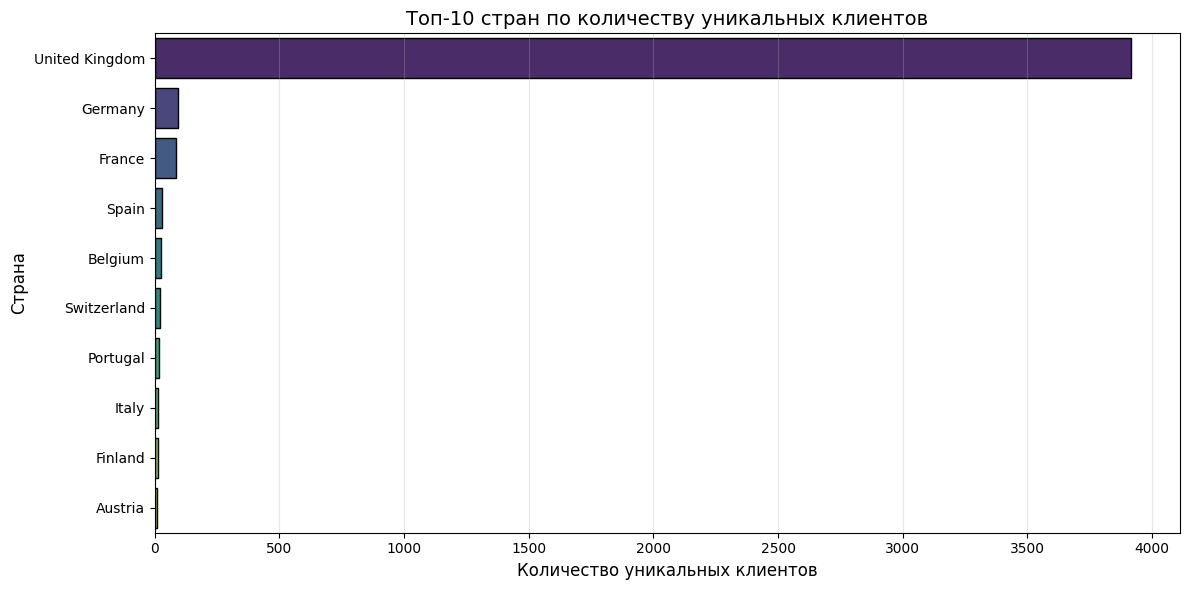


Страна с наибольшим количеством клиентов: United Kingdom
Количество уникальных клиентов: 3916


In [28]:
# Считаем количество уникальных клиентов для каждой страны
clients_per_country = data.groupby('Country')['CustomerID'].nunique().reset_index()
clients_per_country.columns = ['Country', 'Unique Customers']
clients_per_country = clients_per_country.sort_values('Unique Customers', ascending=False)

print("Топ-10 стран по количеству уникальных клиентов:")
print(clients_per_country.head(10))

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(
    data=clients_per_country.head(10),
    x='Unique Customers',
    y='Country',
    palette='viridis'
)
plt.title('Топ-10 стран по количеству уникальных клиентов', fontsize=14)
plt.xlabel('Количество уникальных клиентов', fontsize=12)
plt.ylabel('Страна', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Определяем страну с наибольшим количеством клиентов
top_country = clients_per_country.iloc[0]
print(f"\nСтрана с наибольшим количеством клиентов: {top_country['Country']}")
print(f"Количество уникальных клиентов: {top_country['Unique Customers']}")

### Задание 4.2
Мы посмотрели на распределение клиентов в разрезе стран. А что насчёт заказов?

Постройте визуализацию и выделите топ-3 стран по количеству поступающих заказов.

* Великобритания (United Kingdom)
* Германия (Germany)
* Франция (France)
* Нидерланды (Netherlands)
* Ирландия (EIRE)
* Австралия (Australia)


Топ-10 стран по количеству заказов:
           Country  Number of Orders
36  United Kingdom             17901
14         Germany               443
13          France               382
10            EIRE               282
3          Belgium                98
24     Netherlands                93
31           Spain                88
0        Australia                56
33     Switzerland                50
27        Portugal                50


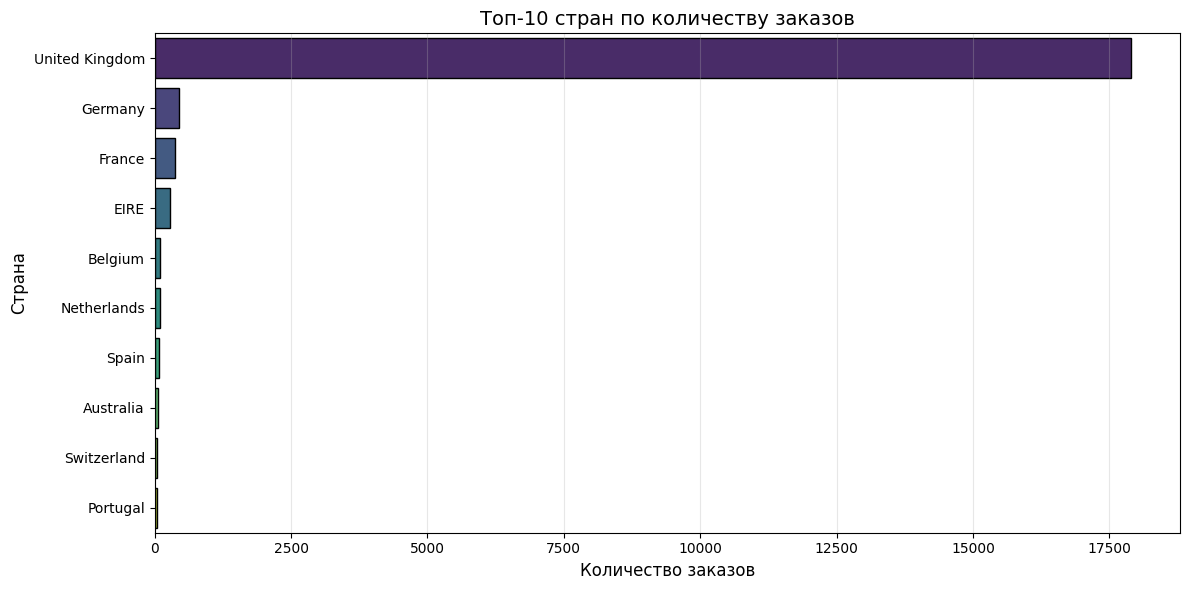


Топ-3 стран по количеству заказов:
  37. United Kingdom: 17901 заказов
  15. Germany: 443 заказов
  14. France: 382 заказов


In [29]:
# Считаем количество уникальных заказов для каждой страны
orders_per_country = data.groupby('Country')['InvoiceNo'].nunique().reset_index()
orders_per_country.columns = ['Country', 'Number of Orders']
orders_per_country = orders_per_country.sort_values('Number of Orders', ascending=False)

print("Топ-10 стран по количеству заказов:")
print(orders_per_country.head(10))

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(
    data=orders_per_country.head(10),
    x='Number of Orders',
    y='Country',
    palette='viridis'
)
plt.title('Топ-10 стран по количеству заказов', fontsize=14)
plt.xlabel('Количество заказов', fontsize=12)
plt.ylabel('Страна', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Выделяем топ-3
print("\nТоп-3 стран по количеству заказов:")
for i, row in orders_per_country.head(3).iterrows():
    print(f"  {i+1}. {row['Country']}: {row['Number of Orders']} заказов")

### Задание 4.3
Давайте добавим в датасет общую цену заказа, назовём её TotalPrice.
Общая цена заказа рассчитывается как:
 
 **общая цена = цена за единицу товара * (количество товаров в заказе - количество возвращённых товаров).**

Чему равна средняя общая стоимость заказов? Ответ приведите в фунтах стерлингов и округлите до целого числа.



In [30]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,key,QuantityCanceled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,17850_85123A_6,0.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,17850_71053_6,0.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,17850_84406B_8,0.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,17850_84029G_6,0.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,17850_84029E_6,0.0


In [31]:
# Добавляем столбец TotalPrice
data['TotalPrice'] = data['UnitPrice'] * (data['Quantity'] - data['QuantityCanceled'])

# Вычисляем среднюю общую стоимость заказов
average_total_price = data['TotalPrice'].mean()

print(f"Средняя общая стоимость заказа: {average_total_price:.2f} фунтов стерлингов")
print(f"Округлённо до целого: {round(average_total_price)}")

Средняя общая стоимость заказа: 18.68 фунтов стерлингов
Округлённо до целого: 19


### Задание 4.4

Постройте визуализацию и выделите топ-3 стран, клиенты из которых приносят компании больше всего выручки:
* Великобритания (United Kingdom)
* Германия (Germany)
* Франция (France)
* Нидерланды (Netherlands)
* Ирландия (EIRE)
* Австралия (Australia)


Топ-10 стран по выручке:
           Country  Total Revenue
36  United Kingdom     8269118.75
24     Netherlands      283443.54
10            EIRE      260731.82
14         Germany      201129.28
13          France      182263.90
0        Australia      136950.25
33     Switzerland       52487.40
31           Spain       51764.90
3          Belgium       36673.04
32          Sweden       36354.41


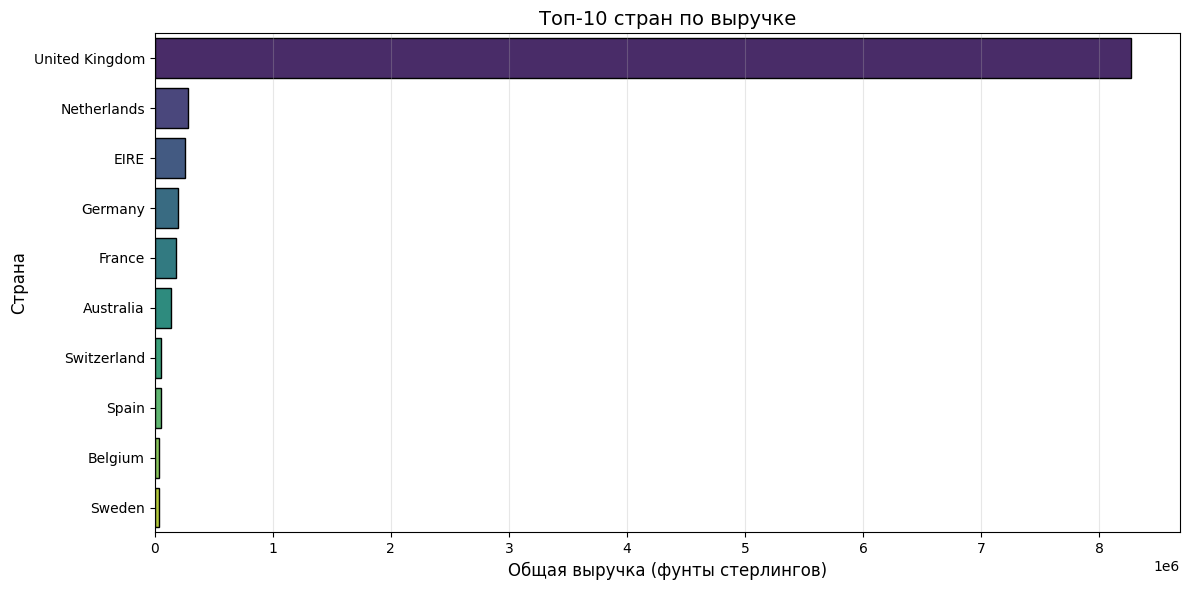


Топ-3 стран по выручке:
  37. United Kingdom: 8269118.75 фунтов
  25. Netherlands: 283443.54 фунтов
  11. EIRE: 260731.82 фунтов


In [32]:
# Группируем данные по странам и считаем общую выручку
revenue_by_country = data.groupby('Country')['TotalPrice'].sum().reset_index()
revenue_by_country.columns = ['Country', 'Total Revenue']
revenue_by_country = revenue_by_country.sort_values('Total Revenue', ascending=False)

print("Топ-10 стран по выручке:")
print(revenue_by_country.head(10))

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(
    data=revenue_by_country.head(10),
    x='Total Revenue',
    y='Country',
    palette='viridis'
)
plt.title('Топ-10 стран по выручке', fontsize=14)
plt.xlabel('Общая выручка (фунты стерлингов)', fontsize=12)
plt.ylabel('Страна', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Выводим топ-3
print("\nТоп-3 стран по выручке:")
for i, row in revenue_by_country.head(3).iterrows():
    print(f"  {i+1}. {row['Country']}: {row['Total Revenue']:.2f} фунтов")

Теперь займёмся временными характеристиками.


### Задание 4.5
Добавьте в таблицу с транзакциями признаки месяца, дня недели и часа совершения покупки.

Постройте визуализацию, отражающую распределение суммарной выручки от заказов по месяцам. Укажите номер самого прибыльного для компании месяца. Предположите, почему так происходит.

Первые строки с новыми признаками:
          InvoiceDate  Month  DayOfWeek  Hour  TotalPrice
0 2010-12-01 08:26:00     12          2     8       15.30
1 2010-12-01 08:26:00     12          2     8       20.34
2 2010-12-01 08:26:00     12          2     8       22.00
3 2010-12-01 08:26:00     12          2     8       20.34
4 2010-12-01 08:26:00     12          2     8       20.34

Выручка по месяцам:
    Month  TotalRevenue
0       1     561361.73
1       2     501287.36
2       3     677999.73
3       4     508757.64
4       5     727833.51
5       6     684192.56
6       7     677319.02
7       8     702966.62
8       9    1014128.18
9      10    1066474.53
10     11    1434784.53
11     12    1205692.69

Самый прибыльный месяц: 11
Выручка за этот месяц: 1434784.53 фунтов


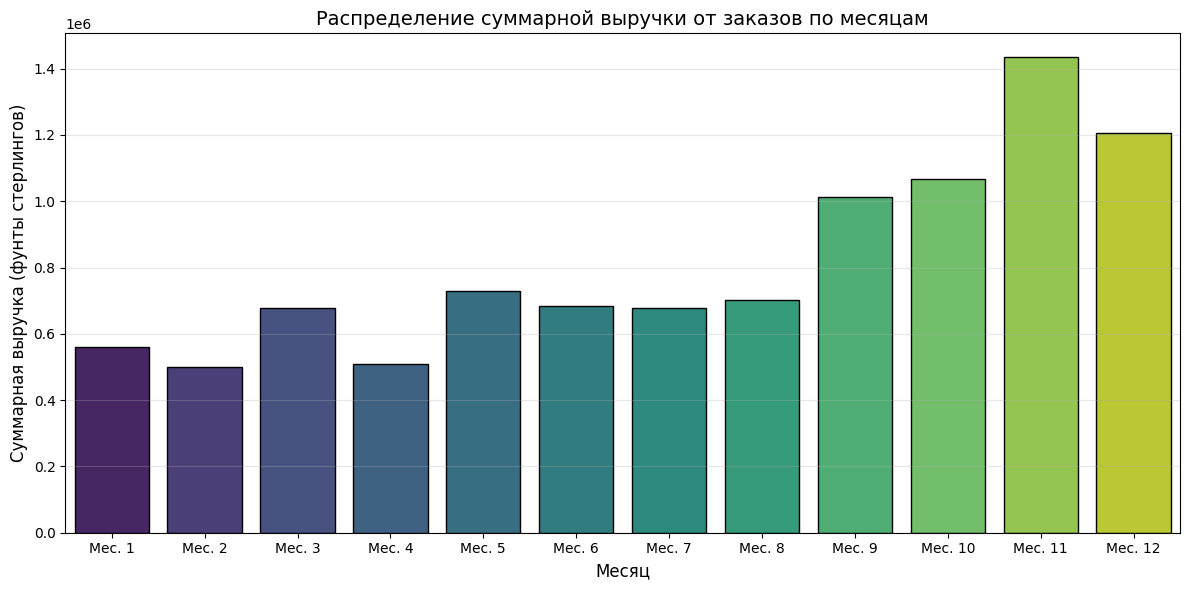

In [33]:
# Добавляем признаки месяца, дня недели и часа
data['Month'] = data['InvoiceDate'].dt.month
data['DayOfWeek'] = data['InvoiceDate'].dt.dayofweek  # 0 = понедельник, 6 = воскресенье
data['Hour'] = data['InvoiceDate'].dt.hour

# Проверяем результат
print("Первые строки с новыми признаками:")
print(data[['InvoiceDate', 'Month', 'DayOfWeek', 'Hour', 'TotalPrice']].head())

# Группируем по месяцам и считаем суммарную выручку
monthly_revenue = data.groupby('Month')['TotalPrice'].sum().reset_index()
monthly_revenue.columns = ['Month', 'TotalRevenue']

print("\nВыручка по месяцам:")
print(monthly_revenue)

# Находим самый прибыльный месяц
best_month = monthly_revenue.loc[monthly_revenue['TotalRevenue'].idxmax()]
print(f"\nСамый прибыльный месяц: {int(best_month['Month'])}")
print(f"Выручка за этот месяц: {best_month['TotalRevenue']:.2f} фунтов")

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(
    data=monthly_revenue,
    x='Month',
    y='TotalRevenue',
    palette='viridis'
)
plt.title('Распределение суммарной выручки от заказов по месяцам', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Суммарная выручка (фунты стерлингов)', fontsize=12)
plt.xticks(range(12), [f'Мес. {i}' for i in range(1, 13)])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Выводы:**

*Ноябрь может быть самым прибыльным по следующим причинам:*

Подготовка к Рождеству — компания продаёт уникальные подарки на все случаи жизни. Ноябрь — это начало рождественского сезона покупок, когда люди активно закупают подарки для родственников и друзей.

Чёрная пятница (Black Friday) — в последнюю пятницу ноября проходят масштабные распродажи, которые стимулируют покупательскую активность.

Корпоративные заказы — в ноябре компании начинают закупать корпоративные подарки для сотрудников и партнёров к новогодним праздникам.

### Задание 4.6
Постройте визуализацию количества заказов для каждого дня недели. Укажите день недели, в который, согласно данным, не совершено ни одного заказа:
* Понедельник
* Вторник
* Среда
* Четверг
* Пятница
* Суббота 
* Воскресенье


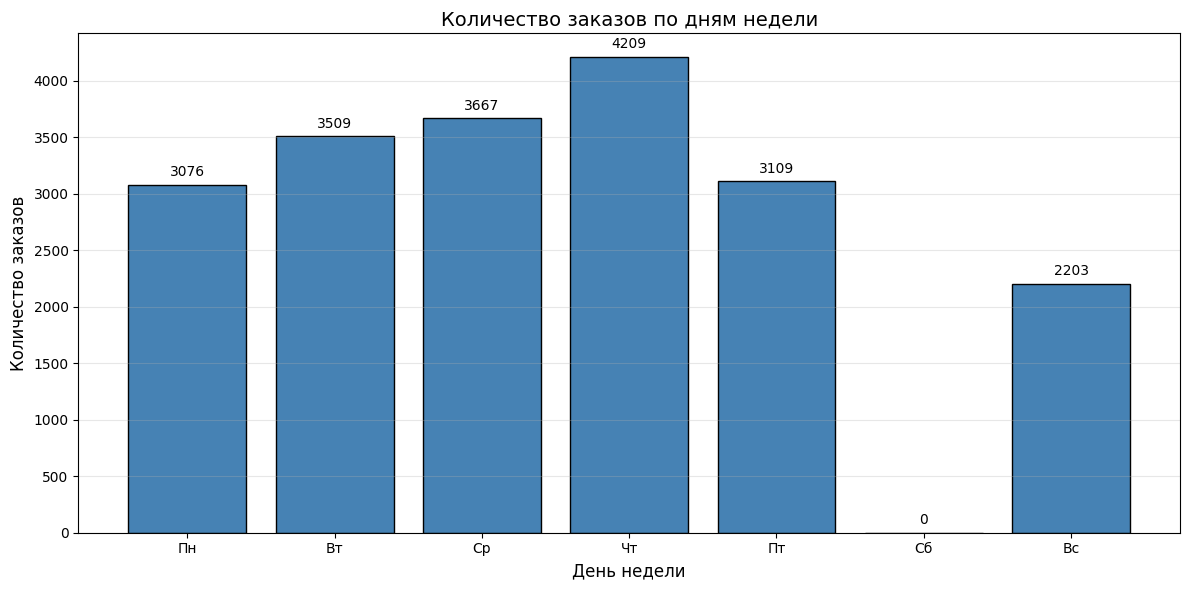


Дни без заказов: ['Сб']


In [34]:
# Считаем количество заказов по дням недели
orders_per_day = data.groupby('DayOfWeek')['InvoiceNo'].nunique()
orders_per_day = orders_per_day.reindex(range(7), fill_value=0)

day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

plt.figure(figsize=(12, 6))
bars = plt.bar(day_names, orders_per_day.values, color='steelblue', edgecolor='black')

# Добавляем значения над столбцами
for bar, count in zip(bars, orders_per_day.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             str(count), ha='center', va='bottom', fontsize=10)

plt.title('Количество заказов по дням недели', fontsize=14)
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Находим дни без заказов
zero_days = [day_names[i] for i, count in enumerate(orders_per_day.values) if count == 0]
print(f"\nДни без заказов: {zero_days}")

### Задание 4.7
Выделите дату из признака времени совершения транзакции.
Сгруппируйте данные по датам и часам совершения транзакции и найдите количество заказов на каждый день-час. Затем найдите среднее количество ежедневно поступающих заказов в каждый из часов.

Постройте визуализацию, отражающую распределение среднего количества ежедневно поступающих заказов по времени суток (часу совершения транзакции).

Выберите верные утверждения:
* Больше всего заказов совершается в дневное время в интервале от 18 до 20 часов
* Больше всего заказов совершается в вечернее время в интервале от 10 до 15 часов
* Начиная с 21 часа вечера и до 6 утра (не включительно) заказы не поступают 
* Заказы поступают во все периоды дня


Пример сгруппированных данных:
         Date  Hour  OrderCount
0  2010-12-01     8           6
1  2010-12-01     9          16
2  2010-12-01    10          11
3  2010-12-01    11          12
4  2010-12-01    12          22
5  2010-12-01    13          12
6  2010-12-01    14          11
7  2010-12-01    15          15
8  2010-12-01    16          16
9  2010-12-01    17           6

Среднее количество заказов по часам:
    Hour  AvgOrders
0      6   1.000000
1      7   1.260870
2      8   2.756098
3      9   5.837302
4     10   7.719472
5     11   7.805921
6     12  10.508197
7     13   9.009901
8     14   8.009934
9     15   7.674419
10    16   4.781818
11    17   3.213592
12    18   3.490909
13    19   2.959184
14    20   1.285714


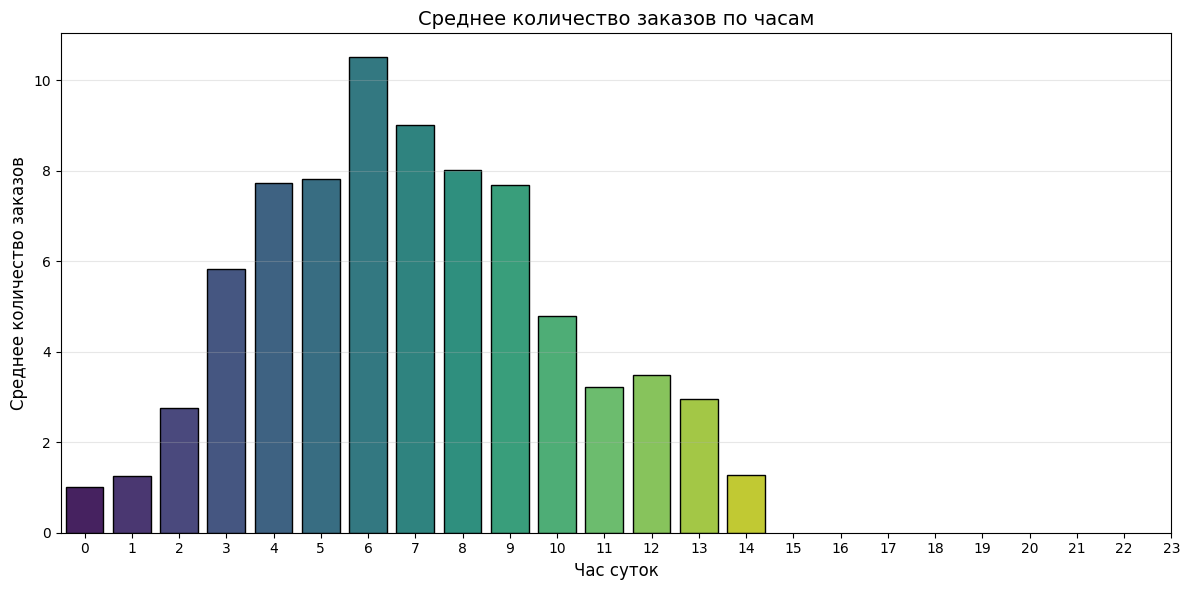


=== Анализ ===
Час с максимальным числом заказов: 12

Часы, в которые заказы НЕ поступают:
  Все часы имеют заказы

=== Проверка утверждений ===
Сумма заказов 10-15 ч: 50.73
Сумма заказов 18-20 ч: 7.74
Сумма заказов 21-6 ч: 0.00


In [35]:
# 1. Выделяем дату из InvoiceDate
data['Date'] = data['InvoiceDate'].dt.date

# 2. Группируем по дате и часу, считаем количество уникальных заказов
orders_per_day_hour = (
    data.groupby(['Date', 'Hour'])['InvoiceNo']
    .nunique()
    .reset_index()
    .rename(columns={'InvoiceNo': 'OrderCount'})
)

print("Пример сгруппированных данных:")
print(orders_per_day_hour.head(10))

# 3. Находим среднее количество заказов по каждому часу
avg_orders_per_hour = orders_per_day_hour.groupby('Hour')['OrderCount'].mean().reset_index()
avg_orders_per_hour.columns = ['Hour', 'AvgOrders']

print("\nСреднее количество заказов по часам:")
print(avg_orders_per_hour)

# 4. Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(
    data=avg_orders_per_hour,
    x='Hour',
    y='AvgOrders',
    palette='viridis'
)
plt.title('Среднее количество заказов по часам', fontsize=14)
plt.xlabel('Час суток', fontsize=12)
plt.ylabel('Среднее количество заказов', fontsize=12)
plt.xticks(range(24), range(24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Анализ результатов
print("\n=== Анализ ===")
print(f"Час с максимальным числом заказов: {avg_orders_per_hour.loc[avg_orders_per_hour['AvgOrders'].idxmax(), 'Hour']}")
print(f"\nЧасы, в которые заказы НЕ поступают:")
zero_hours = avg_orders_per_hour[avg_orders_per_hour['AvgOrders'] == 0]['Hour'].tolist()
print(f"  {zero_hours if zero_hours else 'Все часы имеют заказы'}")

# Проверка интервалов
print("\n=== Проверка утверждений ===")
day_interval = avg_orders_per_hour[
    (avg_orders_per_hour['Hour'] >= 10) & (avg_orders_per_hour['Hour'] <= 15)
]['AvgOrders'].sum()
evening_interval = avg_orders_per_hour[
    (avg_orders_per_hour['Hour'] >= 18) & (avg_orders_per_hour['Hour'] <= 20)
]['AvgOrders'].sum()
night_interval = avg_orders_per_hour[
    (avg_orders_per_hour['Hour'] >= 21) | (avg_orders_per_hour['Hour'] < 6)
]['AvgOrders'].sum()

print(f"Сумма заказов 10-15 ч: {day_interval:.2f}")
print(f"Сумма заказов 18-20 ч: {evening_interval:.2f}")
print(f"Сумма заказов 21-6 ч: {night_interval:.2f}")

In [36]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,key,QuantityCanceled,TotalPrice,Month,DayOfWeek,Hour,Date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,17850_85123A_6,0.0,15.30,12,2,8,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,17850_71053_6,0.0,20.34,12,2,8,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,17850_84406B_8,0.0,22.00,12,2,8,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,17850_84029G_6,0.0,20.34,12,2,8,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,17850_84029E_6,0.0,20.34,12,2,8,2010-12-01


In [ ]:
data.to_csv('client_clustering.csv', index=False)



In [66]:
data = pd.read_csv(
    'client_clustering.csv',
    encoding="ISO-8859-1", 
    dtype={'CustomerID': str,'InvoiceID': str}
)


data.head()

,Unnamed: 0,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,key,QuantityCanceled,TotalPrice,Month,DayOfWeek,Hour,Date
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,17850_85123A_6,0.0,15.30,12,2,8,2010-12-01
1,1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,17850_71053_6,0.0,20.34,12,2,8,2010-12-01
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,17850_84406B_8,0.0,22.00,12,2,8,2010-12-01
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,17850_84029G_6,0.0,20.34,12,2,8,2010-12-01
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,17850_84029E_6,0.0,20.34,12,2,8,2010-12-01


In [67]:
# Удалить уровень индекса с именем "Unnamed"
data = data.drop('Unnamed: 0', axis=1)

In [68]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522504 entries, 0 to 522503
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   InvoiceNo         522504 non-null  int64  
 1   StockCode         522504 non-null  object 
 2   Description       522504 non-null  object 
 3   Quantity          522504 non-null  int64  
 4   InvoiceDate       522504 non-null  object 
 5   UnitPrice         522504 non-null  float64
 6   CustomerID        391150 non-null  object 
 7   Country           522504 non-null  object 
 8   key               522504 non-null  object 
 9   QuantityCanceled  522504 non-null  float64
 10  TotalPrice        522504 non-null  float64
 11  Month             522504 non-null  int64  
 12  DayOfWeek         522504 non-null  int64  
 13  Hour              522504 non-null  int64  
 14  Date              522504 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 59.8+ MB


## 5. RFM-сегментация клиентов: часть 1

Мы добрались до самой интересной части нашей задачи. Нам предстоит сформировать признаки, на основе которых мы будем производить сегментацию клиентов.

Для этого давайте познакомимся с очень популярным методом для анализа потребительской ценности под названием RFM. 

<center> <img src=https://miro.medium.com/max/1400/1*uYQjy9SUjW7iWHc2gGanQQ.png align="right" width="400"/> </center>

Метод заключается в группировке клиентов на основе следующих параметров:
* Recency (Давность) — давность последней покупки клиента;
* Frequency (Частота) — общее количество покупок клиента;
* Monetary Value (Денежная ценность) — сколько денег потратил клиент.


Суть RFM-анализа состоит в том, что мы разделяем всех клиентов на группы в зависимости от того, как давно они сделали последнюю покупку, как часто покупали и насколько большой была сумма их заказов.

Например, вот так может выглядеть интерпретация кластеров для случая RF-сегментации (анализа на основе давности и частоты заказов клиента):

<img src=https://retailrocket.ru/wp-content/uploads/2017/06/rfm-1.png>

Задача маркетологов — вести клиента в зону лояльных.

Мы можем рассчитать RFM-характеристики для каждого из клиентов в нашем датасете и на их основе с помощью методов кластеризации построить подобные сегменты клиентов, привязанные к нашим данным.

### Задание 5.1

Итак, приступим к созданию нашей RFM-таблицы. 

Чтобы получить RFM-таблицу, нам необходимо сгруппировать данные по идентификаторам клиента и рассчитать следующие  агрегированные характеристики:

* Recency для i-го клиента рассчитывается как разница между датой и временем последнего заказа и точкой отсчёта, переведённая в дни:
    $$t_0-max(t_{i1}, t_{i2},..., t_{iM})$$

    где $t_{ij}$ — дата и время совершения i-ым клиентом своей j-ой покупки.

    В качестве точки отсчёта $t_0$ берём дату на один день «старше», чем все наши данные. Это будет 10 декабря 2011 года (в формате datetime — '2011-12-10 00:00:00').

* Frequency рассчитывается как общее количество уникальных заказов, которые совершил i-ый клиент.
* Monetary Value рассчитывается как общая сумма денег, которую i-ый клиент потратил на наши товары (с учетом возвратов).

Когда вы рассчитаете все характеристики, не забудьте дать столбцам результирующей таблицы соответствующие названия.

In [72]:
# Преобразуем InvoiceDate в datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Теперь группировка сработает
t0 = pd.Timestamp('2011-12-10 00:00:00')

rfm_table = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (t0 - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                         # Frequency
    'TotalPrice': 'sum'                             # Monetary
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency', 
    'TotalPrice': 'Monetary'
}).reset_index()

print("RFM-таблица (первые 10 строк):")
print(rfm_table.head(10))
print(f"\nРазмер таблицы: {rfm_table.shape[0]} клиентов")

RFM-таблица (первые 10 строк):
  CustomerID  Recency  Frequency  Monetary
0      12346      325          1      0.00
1      12347        2          7   4310.00
2      12348       75          4   1437.24
3      12349       18          1   1457.55
4      12350      310          1    294.40
5      12352       36          7   1265.41
6      12353      204          1     89.00
7      12354      232          1   1079.40
8      12355      214          1    459.40
9      12356       22          3   2487.43

Размер таблицы: 4334 клиентов


In [73]:

print("\n" + "="*60)
print("ОТВЕТЫ НА ВОПРОСЫ ЗАДАНИЯ 5.1")
print("="*60)

# 1. Сколько клиентов совершили покупку более 200 дней назад?
customers_over_200 = (rfm_table['Recency'] > 200).sum()
print(f"1. Клиентов с покупкой > 200 дней назад: {customers_over_200}")

# 2. Сколько заказов в среднем делает клиент?
avg_orders = round(rfm_table['Frequency'].mean())
print(f"2. Среднее количество заказов на клиента: {avg_orders}")

# 3. Общая сумма денег, которую потратил клиент 12360
customer_12360 = rfm_table[rfm_table['CustomerID'] == '12360']
if len(customer_12360) > 0:
    total_12360 = round(customer_12360['Monetary'].values[0])
    print(f"3. Клиент 12360 потратил: {total_12360} фунтов стерлингов")
else:
    print("3. Клиент 12360 не найден в таблице")


ОТВЕТЫ НА ВОПРОСЫ ЗАДАНИЯ 5.1
1. Клиентов с покупкой > 200 дней назад: 743
2. Среднее количество заказов на клиента: 4
3. Клиент 12360 потратил: 2302 фунтов стерлингов


1) Сколько клиентов совершили покупку более 200 дней назад?

2) Сколько заказов в среднем делает клиент (за представленный годовой период)? Ответ округлите до целого числа.

3) Чему равна общая сумма денег, которую потратил клиент с идентификатором 12360? Ответ приведите в фунтах стерлингов и округлите до целого числа.



Теперь давайте взглянем на коробчатые диаграммы для каждого из признаков:

In [74]:
# Используем только RFM-столбцы (без CustomerID)
rfm_columns = ['Recency', 'Frequency', 'Monetary']

boxes = [px.box(rfm_table, x=column) for column in rfm_columns]
fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=("Recency", "Frequency", "Monetary")
)

for i, box in enumerate(boxes):
    fig.add_trace(boxes[i]['data'][0], row=1, col=i+1)

fig.update_layout(showlegend=True)

fig.show()

Что интересного здесь можно увидеть? Есть клиенты с аномально большим количеством сделанных заказов (более 100 штук), а также клиенты, общая стоимость заказов которых превышает 190 тысяч фунтов стерлингов.

Чем это плохо? Выбросы могут отрицательно сказаться на результатах работы методов кластеризации, неустойчивых к ним, например алгоритма KMeans, поэтому хотелось бы от них избавиться. Однако терять много ценных данных о клиентах тоже не хочется, поэтому ограничимся верхней границей соответствующей квантили уровня 0.95. Таким образом, мы удалим данные тех клиентов, для которых значение параметра Frequency или параметра Monetary выше, чем у 95 % клиентов.


### Задание 5.2
Удалите из RFM-таблицы записи о клиентах, для которых выполняется хотя бы одно из условий:

$$frequency >frequency_{0.95}$$
$$monetary >monetary_{0.95}$$ 

где $frequency_{0.95}$ и $monetary_{0.95}$ - квантили уровня 0.95 для соответствующих признаков. 

Данные о скольких клиентах у вас остались в RFM-таблице?


In [78]:
# Вычисляем квантили уровня 0.95
freq_quantile = rfm_table['Frequency'].quantile(0.95)
monetary_quantile = rfm_table['Monetary'].quantile(0.95)

print(f"Квантиль Frequency (0.95): {freq_quantile}")
print(f"Квантиль Monetary (0.95): {monetary_quantile}")

# Удаляем выбросы (оставляем только тех клиентов, для которых выполняются ОБА условия)
# Т.е. Frequency <= квантилю И Monetary <= квантилю
rfm_table = rfm_table[
    (rfm_table['Frequency'] <= freq_quantile) & 
    (rfm_table['Monetary'] <= monetary_quantile)
]

print(f"\nКоличество клиентов после удаления выбросов: {len(rfm_table_cleaned)}")
print(f"Было клиентов: {len(rfm_table)}")
print(f"Удалено клиентов: {len(rfm_table) - len(rfm_table_cleaned)}")

Квантиль Frequency (0.95): 13.0
Квантиль Monetary (0.95): 5628.147499999977

Количество клиентов после удаления выбросов: 4044
Было клиентов: 4044
Удалено клиентов: 0


После удаления выбросов у вас должны получиться следующие коробчатые диаграммы:


In [79]:
# Используем обновленные данные
rfm_columns = ['Recency', 'Frequency', 'Monetary']

boxes = [px.box(rfm_table, x=column) for column in rfm_columns]
fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=("Recency", "Frequency", "Monetary")
)

for i, box in enumerate(boxes):
    fig.add_trace(boxes[i]['data'][0], row=1, col=i+1)

fig.update_layout(showlegend=True)

fig.show()

Мы наконец добрались до этапа кластеризации. Для начала нам необходимо оценить, как распределены наблюдения в пространстве признаков. Благо, у нас всего три параметра, по которым мы хотим кластеризовать клиентов, поэтому данные можно визуализировать в виде трёхмерной диаграммы рассеяния. 

Построим визуализацию нашего трёхмерного пространства признаков:


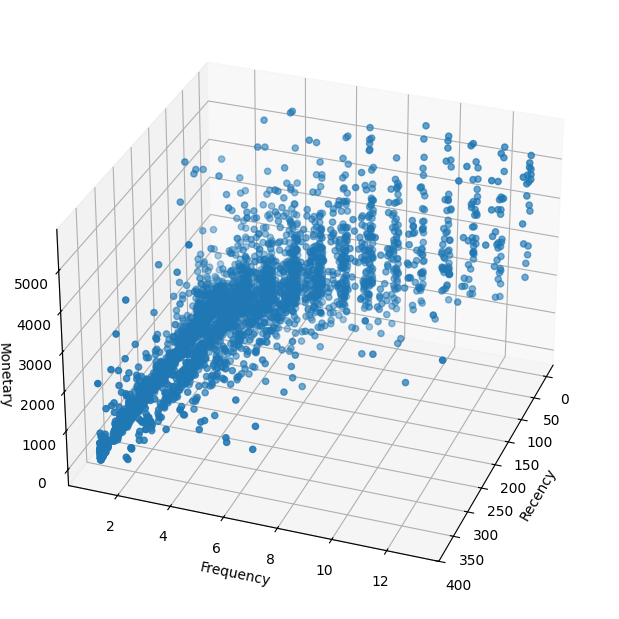

In [82]:
# создадим трёхмерный объект
fig = plt.figure(figsize=(6,6))
ax = Axes3D(fig)
# добавим дополнительную ось в объект картинки
fig.add_axes(ax)
ax.azim = 20
ax.elev = 30

# визуализируем данные, передав значения x, y, z, а также информацию о группировке данных по цветам
ax.scatter(
    rfm_table['Recency'].to_list(), 
    rfm_table['Frequency'].to_list(),
    rfm_table['Monetary'].to_list()
)
# добавим оси
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary');


Что здесь можно увидеть? На самом деле, ничего конкретного. Да, видно, что есть клиенты с большими значениями параметров Monetary и Frequency — вероятно, это лучшие клиенты, которые покупают чаще всего и приносят больше всего денег. Однако по общей массе точек сложно сказать, сколько кластеров у нас есть — скорее даже кажется, что пространство не поддаётся кластеризации.

Давайте призовём на помощь методы снижения размерности.


### Задание 5.3
Начнём с метода главных компонент (PCA). Нам известно, что для его стабильной работы данные необходимо стандартизировать/нормализовать. 

Давайте для удобства обернём эти шаги по предобработке данных в pipeline.

Создайте pipeline, в котором будут следующие шаги:
* стандартизация с помощью StandardScaler с параметрами по умолчанию; 
* метод главных компонент с двумя компонентами.

Обучите ваш pipeline на RFM-таблице, очищенной от выбросов, и примените к ней трансформацию.

Какую долю дисперсии исходных данных объясняет первая главная компонента? Ответ округлите до двух знаков после точки-разделителя.



In [101]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Создаём pipeline: стандартизация + PCA
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

# Выбираем только числовые признаки для PCA (без CustomerID)
features = ['Recency', 'Frequency', 'Monetary']
X = rfm_table[features]

# Обучаем pipeline и применяем трансформацию
rfm_table_processed = pipeline.fit_transform(X)

# Преобразуем результат в DataFrame для удобства
rfm_table_processed = pd.DataFrame(
    rfm_table_processed, 
    columns=['axis-1', 'axis-2'],
    index=rfm_table.index
)

# Получаем долю дисперсии, объясняемую первой главной компонентой
explained_variance = pipeline.named_steps['pca'].explained_variance_ratio_[0]

print(f"Доля дисперсии, объясняемая первой главной компонентой: {explained_variance:.4f}")
print(f"Округлённо до двух знаков: {round(explained_variance, 2)}")

print(f"\nДоля дисперсии по всем компонентам:")
for i, var in enumerate(pipeline.named_steps['pca'].explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")

Доля дисперсии, объясняемая первой главной компонентой: 0.6774
Округлённо до двух знаков: 0.68

Доля дисперсии по всем компонентам:
  PC1: 0.6774 (67.74%)
  PC2: 0.2401 (24.01%)


Визуализировав пространство главных компонент после декомпозиции мы получим следующую картину:

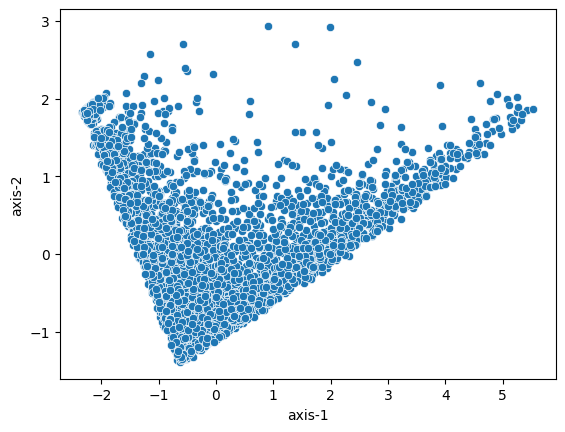

In [102]:
sns.scatterplot(data=rfm_table_processed, x='axis-1', y='axis-2');

Попробуем разделить это пространство главных компонент на сегменты. 

### Задание 5.4
Попробуем воспользоваться методом k-means. 

Подберите оптимальное количество кластеров для метода k-means с помощью коэффициента силуэта, перебирая возможные значения от 2 до 10 включительно. 

В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.

1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.


n_clusters=2: silhouette_score=0.3968
n_clusters=3: silhouette_score=0.5243
n_clusters=4: silhouette_score=0.4911
n_clusters=5: silhouette_score=0.4533
n_clusters=6: silhouette_score=0.4439
n_clusters=7: silhouette_score=0.4131
n_clusters=8: silhouette_score=0.4052
n_clusters=9: silhouette_score=0.4145
n_clusters=10: silhouette_score=0.3894

РЕЗУЛЬТАТЫ:
1. Оптимальное количество кластеров: 3
2. Максимальный коэффициент силуэта: 0.5243
   Округлённо до двух знаков: 0.52


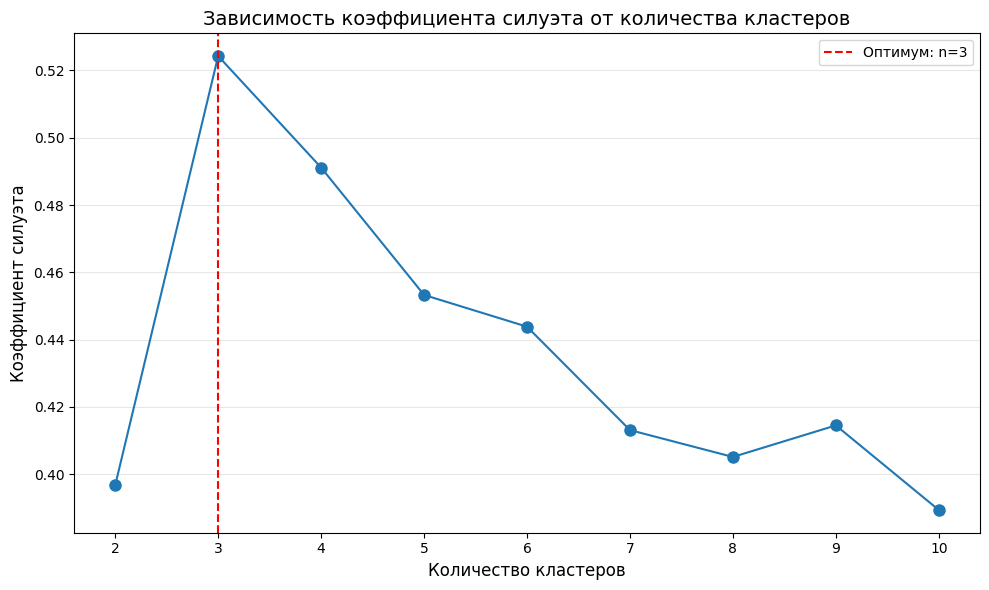

In [103]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Перебираем количество кластеров от 2 до 10
silhouette_scores = []
n_clusters_range = range(2, 11)

for n_clusters in n_clusters_range:
    # Создаём модель K-Means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    
    # Обучаем модель и делаем предсказание
    labels = kmeans.fit_predict(rfm_table_processed)
    
    # Вычисляем коэффициент силуэта
    silhouette_avg = silhouette_score(rfm_table_processed, labels)
    silhouette_scores.append(silhouette_avg)
    
    print(f"n_clusters={n_clusters}: silhouette_score={silhouette_avg:.4f}")

# Находим оптимальное количество кластеров
best_idx = silhouette_scores.index(max(silhouette_scores))
best_n_clusters = n_clusters_range[best_idx]
max_silhouette_score = max(silhouette_scores)

print(f"\n{'='*60}")
print(f"РЕЗУЛЬТАТЫ:")
print(f"{'='*60}")
print(f"1. Оптимальное количество кластеров: {best_n_clusters}")
print(f"2. Максимальный коэффициент силуэта: {max_silhouette_score:.4f}")
print(f"   Округлённо до двух знаков: {round(max_silhouette_score, 2)}")

# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.plot(n_clusters_range, silhouette_scores, marker='o', markersize=8)
plt.xlabel('Количество кластеров', fontsize=12)
plt.ylabel('Коэффициент силуэта', fontsize=12)
plt.title('Зависимость коэффициента силуэта от количества кластеров', fontsize=14)
plt.xticks(n_clusters_range)
plt.grid(axis='y', alpha=0.3)
plt.axvline(x=best_n_clusters, color='r', linestyle='--', label=f'Оптимум: n={best_n_clusters}')
plt.legend()
plt.tight_layout()
plt.show()

### Задание 5.5
Теперь возьмём EM-алгоритм.

Подберите оптимальное количество кластеров для EM-алгоритма (GaussianMixture) с помощью коэффициента силуэта, перебирая возможные значения от 2 до 10 включительно.
В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.


1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.


n_components=2: silhouette_score=0.3605
n_components=3: silhouette_score=0.4361
n_components=4: silhouette_score=0.3481
n_components=5: silhouette_score=0.2512
n_components=6: silhouette_score=0.2670
n_components=7: silhouette_score=0.2506
n_components=8: silhouette_score=0.1550
n_components=9: silhouette_score=0.1468
n_components=10: silhouette_score=0.1268

РЕЗУЛЬТАТЫ EM-АЛГОРИТМА:
1. Оптимальное количество кластеров: 3
2. Максимальный коэффициент силуэта: 0.4361
   Округлённо до двух знаков: 0.44


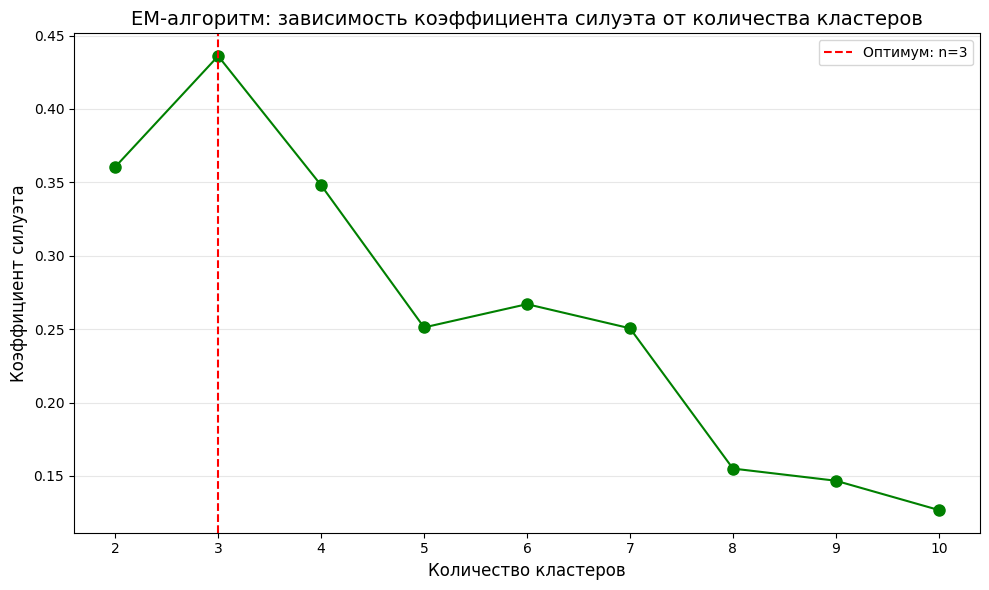

In [104]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Перебираем количество кластеров от 2 до 10
silhouette_scores_em = []
n_components_range = range(2, 11)

for n_components in n_components_range:
    # Создаём модель GaussianMixture (EM-алгоритм)
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    
    # Обучаем модель и делаем предсказание
    labels = gmm.fit_predict(rfm_table_processed)
    
    # Вычисляем коэффициент силуэта
    silhouette_avg = silhouette_score(rfm_table_processed, labels)
    silhouette_scores_em.append(silhouette_avg)
    
    print(f"n_components={n_components}: silhouette_score={silhouette_avg:.4f}")

# Находим оптимальное количество кластеров
best_idx = silhouette_scores_em.index(max(silhouette_scores_em))
best_n_components = n_components_range[best_idx]
max_silhouette_score_em = max(silhouette_scores_em)

print(f"\n{'='*60}")
print(f"РЕЗУЛЬТАТЫ EM-АЛГОРИТМА:")
print(f"{'='*60}")
print(f"1. Оптимальное количество кластеров: {best_n_components}")
print(f"2. Максимальный коэффициент силуэта: {max_silhouette_score_em:.4f}")
print(f"   Округлённо до двух знаков: {round(max_silhouette_score_em, 2)}")

# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, silhouette_scores_em, marker='o', markersize=8, color='green')
plt.xlabel('Количество кластеров', fontsize=12)
plt.ylabel('Коэффициент силуэта', fontsize=12)
plt.title('EM-алгоритм: зависимость коэффициента силуэта от количества кластеров', fontsize=14)
plt.xticks(n_components_range)
plt.grid(axis='y', alpha=0.3)
plt.axvline(x=best_n_components, color='r', linestyle='--', 
            label=f'Оптимум: n={best_n_components}')
plt.legend()
plt.tight_layout()
plt.show()

### Задание 5.6
Давайте посмотрим на распределение кластеров.

1) Сначала нужно определить лучшую модель. Для какой модели с оптимальным количеством кластеров коэффициент силуэта наибольший?
* K-Means
* GaussianMixture


2) Обучите лучшую модель с подобранным ранее количеством кластеров на декомпозированных данных. 
Сколько клиентов попало в самый большой кластер?



In [106]:
from sklearn.cluster import KMeans
import numpy as np

# Оптимальное количество кластеров из задания 5.4
best_n_clusters = 3

# Обучаем K-means на PCA-компонентах
kmeans_best = KMeans(n_clusters=best_n_clusters, random_state=42)
labels = kmeans_best.fit_predict(rfm_table_processed)

# Считаем количество клиентов в каждом кластере
cluster_counts = np.bincount(labels)

print("Распределение клиентов по кластерам:")
for i, count in enumerate(cluster_counts):
    print(f"  Кластер {i}: {count} клиентов")

# Размер самого большого кластера
max_cluster_size = cluster_counts.max()
print(f"\nРазмер самого большого кластера: {max_cluster_size}")

Распределение клиентов по кластерам:
  Кластер 0: 999 клиентов
  Кластер 1: 2269 клиентов
  Кластер 2: 776 клиентов

Размер самого большого кластера: 2269


Визуализируем результаты кластеризации:

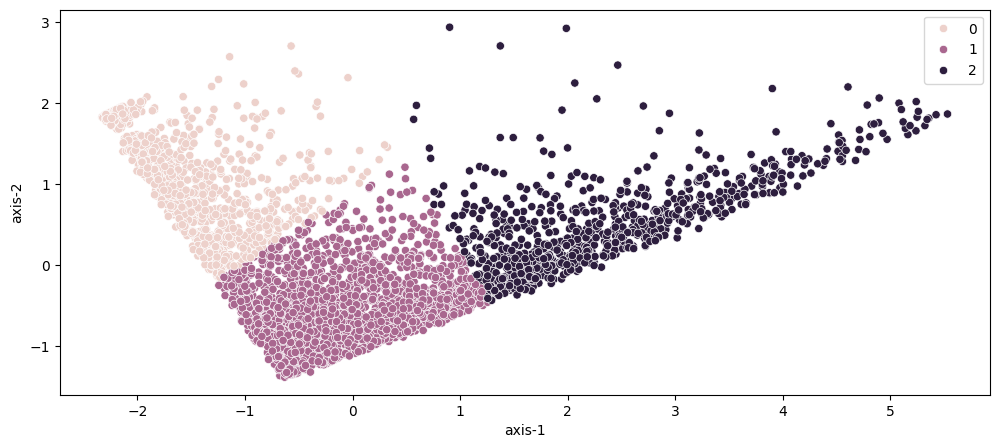

In [107]:
fig = plt.figure(figsize=(12, 5))
sns.scatterplot(
    data=rfm_table_processed, 
    x='axis-1', 
    y='axis-2', 
    hue=labels,
);

Итак, у нас есть три сегмента клиентов. Давайте попробуем составить профиль для этих сегментов.

### Задание 5.7

Для составления профиля кластеров нам необходимо вернуться от декомпозированных данных к RFM-таблице, очищенной от выбросов.  Сгруппируйте RFM-таблицу по полученным кластерам и рассчитайте среднее по каждому из признаков.

Чему равно максимальное среднее значение признака Frequency в полученной таблице? Ответ округлите до целого числа.

In [110]:

# Добавляем метки кластеров в RFM-таблицу (очищенную от выбросов)
rfm_table = rfm_table.copy()
rfm_table['cluster'] = labels

# Группируем по кластерам и считаем среднее по каждому признаку
cluster_profiles = rfm_table.groupby('cluster')[['Recency', 'Frequency', 'Monetary']].mean()

print("Профили кластеров (средние значения):")
print(cluster_profiles)


# Находим максимальное среднее значение Frequency
max_frequency = cluster_profiles['Frequency'].max()
print(f"Максимальное среднее значение Frequency: {max_frequency:.4f}")
print(f"Округлённо до целого: {round(max_frequency)}")

# Дополнительная визуализация для анализа профилей
print("\n" + "="*60)
print("ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ")
print("="*60)

for cluster_id in cluster_profiles.index:
    profile = cluster_profiles.loc[cluster_id]
    print(f"\nКластер {cluster_id}:")
    print(f"  Recency: {profile['Recency']:.1f} дней с последней покупки")
    print(f"  Frequency: {profile['Frequency']:.1f} заказов")
    print(f"  Monetary: {profile['Monetary']:.2f} фунтов")
    
    # Определяем тип клиента
    if profile['Frequency'] > cluster_profiles['Frequency'].mean():
        print(f"  → Частый покупатель")
    if profile['Monetary'] > cluster_profiles['Monetary'].mean():
        print(f"  → Высокий средний чек")
    if profile['Recency'] < cluster_profiles['Recency'].mean():
        print(f"  → Активный клиент (недавно покупал)")

Профили кластеров (средние значения):
            Recency  Frequency     Monetary
cluster                                    
0        253.474474   1.403403   386.170480
1         51.221684   2.329220   659.793658
2         31.943299   7.067010  2657.388943
Максимальное среднее значение Frequency: 7.0670
Округлённо до целого: 7

ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ

Кластер 0:
  Recency: 253.5 дней с последней покупки
  Frequency: 1.4 заказов
  Monetary: 386.17 фунтов

Кластер 1:
  Recency: 51.2 дней с последней покупки
  Frequency: 2.3 заказов
  Monetary: 659.79 фунтов
  → Активный клиент (недавно покупал)

Кластер 2:
  Recency: 31.9 дней с последней покупки
  Frequency: 7.1 заказов
  Monetary: 2657.39 фунтов
  → Частый покупатель
  → Высокий средний чек
  → Активный клиент (недавно покупал)


### Полярная диаграмма
Сейчас мы познакомимся с одним из способов визуализации профиля кластеров — Radar Chart (полярная, или лепестковая, диаграмма). Это графическое представление значений нескольких эквивалентных категорий в форме «паутины».
Radar Chart очень часто используется в контексте определения профиля кластеров. На концах «паутины» откладываются оси, которые соответствуют признакам, описывающим объекты. На каждой из осей для каждого кластера откладываются средние значения соответствующих характеристик. Соединив точки по осям, мы получаем многоугольник. 
Пример полярной диаграммы для задачи кластеризации учеников по интересам:

<img src=https://www.datanovia.com/en/wp-content/uploads/2020/12/radar-chart-in-r-customized-fmstb-radar-chart-1.png width=500>

На данной диаграмме мы видим визуализацию признаков для одного из кластеров. Видно, что ученики, принадлежащие к данному кластеру, в большей степени увлекаются музыкой (Music), а в меньшей степени — программированием (Programm).

В модуле graph_objects библиотеки plotly есть встроенная функция Scatterpolar, которая позволяет построить полярную диаграмму. На основе этой функции мы реализовали собственную функцию plot_cluster_profile(), которая позволяет визуализировать профиль каждого из кластеров в виде полярной диаграммы. У этой функции два параметра: grouped_data — сгруппированные по кластерам характеристики объектов (клиентов), n_clusters — количество кластеров. 

Главное условие использования полярной диаграммы — все признаки должны быть приведены к единому масштабу с помощью нормализации, где 1 будет означать максимум, а 0 — минимум. Шаг с нормализацией мы также добавили в реализацию функции plot_cluster_profile().

In [111]:
def plot_cluster_profile(grouped_data, n_clusters):
    # Нормализуем сгруппированные данные, приводя их к масштабу 0-1.
    scaler = preprocessing.MinMaxScaler()
    grouped_data = pd.DataFrame(scaler.fit_transform(grouped_data), columns=grouped_data.columns)
    # Создаем список признаков
    features = grouped_data.columns
    # Создаем пустую фигуру
    fig = go.Figure()
    # В цикле визуализируем полярную диаграмму для каждого кластера
    for i in range(n_clusters):
        # Создаем полярную диаграмму и добавляем ее на общий график
        fig.add_trace(go.Scatterpolar(
            r=grouped_data.iloc[i].values, # радиусы
            theta=features, # название засечек
            fill='toself', # заливка многоугольника цветом
            name=f'Cluster {i}', # название - номер кластера
        ))
    # Обновляем параметры фигуры
    fig.update_layout(
        showlegend=True, # отображение легенды
        autosize=False, # устаналиваем свои размеры графика
        width=800, # ширина (в пикселях)
        height=800, # высота (в пикселях)
    )
    # Отображаем фигуру
    fig.show()
    

Теперь у нас есть удобный инструмент для анализа профиля кластеров. Давайте воспользуемся им.


### Задание 5.8

Визуализируйте профили кластеров в виде полярной диаграммы на основе средних RFM-характеристик, вычисленных для каждого кластера. 

Проанализируйте кластеры и на основе анализа сопоставьте номер кластера и его описание.

Описание кластера:
* Кластер соответствует «лояльным» клиентам, которые приносят наибольший доход, совершают покупки чаще всего, а давность их последней покупки наименьшая.
* Кластер соответствует «промежуточным» клиентам, которые являются активными, но покупают не так часто и много, как лояльные клиенты. В то же время эти клиенты не являются «потерянными».
* Кластер соответствует «потерянным» клиентам, которые купили меньше всего товара, и их последняя покупка была совершена очень давно.


In [ ]:
# подготовка данных для визуализации

# Убеждаемся, что метки кластеров добавлены в таблицу
rfm_table['cluster'] = labels

# Группируем по кластерам и считаем средние значения RFM-признаков
cluster_profiles = rfm_table.groupby('cluster')[['Recency', 'Frequency', 'Monetary']].mean()

print("Средние значения RFM по кластерам:")
print(cluster_profiles)

Средние значения RFM по кластерам:
            Recency  Frequency     Monetary
cluster                                    
0        253.474474   1.403403   386.170480
1         51.221684   2.329220   659.793658
2         31.943299   7.067010  2657.388943


In [114]:
# Визуализируем профили кластеров - полярная диаграмма
plot_cluster_profile(cluster_profiles, n_clusters=3)

### 4. RFM-сегментация клиентов: часть 2

Итак, с помощью RFM-анализа нам удалось выделить три сегмента клиентов. Однако в маркетинге принято оперировать большим их количеством: обычно маркетологи стараются создать стратегию хотя бы для пяти-семи клиентских сегментов в градации от «лояльных» до «потерянных» с промежуточными категориями.

Поэтому, получив обратную связь от маркетологов, мы вновь принимаемся за работу, пытаясь модифицировать полученное решение.

Ранее мы производили кластеризацию в пространстве главных компонент. Вспомним, что PCA является линейным методом отображения исходного пространства признаков в его сжатую версию.

А что если использовать нелинейную трансформацию? Например, алгоритм снижения размерности t-SNE. Давайте попробуем и посмотрим, что получится.

### Задание 6.1
Воспользуемся алгоритмом t-SNE и трансформируем RFM-таблицу, очищенную от выбросов, в двухмерное представление. Также заранее позаботимся о масштабировании признаков.

Давайте для удобства обернём шаги по предобработке данных в pipeline.

Создайте pipeline, который будет содержать следующие шаги:
* стандартизация с помощью StandardScaler с параметрами по умолчанию; 
* алгоритм t-SNE с двумя компонентами, параметрами perplexity=50 и random_state=100.

Обучите ваш pipeline на RFM-таблице (очищенной от выбросов), полученной ранее, и примените к ней трансформацию.

Чему равно значение дивергенции Кульбака — Лейблера для обученного алгоритма t-SNE? Ответ округлите до двух знаков после точки-разделителя.

**Примечание:**
Напомним, что дивергенция Кульбака-Лейблера - это функция потерь, которая минимизируется при обучения алгоритма t-SNE. Она показывает меру расстояния между двумя распределениями. 

Оптимальное значение данной характеристики, найденное в процессе обучения алгоритма t-SNE, хранится в атрибуте kl_divergence_ объекта класса TSNE из библиотеки sklearn. Конечно же, предварительно модель необходимо обучить, чтобы получить это значение.



In [117]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Убеждаемся, что в таблице только RFM-признаки (без меток кластеров)
features = ['Recency', 'Frequency', 'Monetary']
X_rfm = rfm_table[features]  # используем очищенную от выбросов таблицу

# Создаём pipeline: стандартизация + t-SNE
pipeline_tsne = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, perplexity=50, random_state=100))
])

# Обучаем pipeline и применяем трансформацию
rfm_table_tsne = pipeline_tsne.fit_transform(X_rfm)

# Преобразуем результат в DataFrame для удобства
rfm_table_tsne = pd.DataFrame(
    rfm_table_tsne,
    columns=['axis-1', 'axis-2'],
    index=X_rfm.index
)

print("Результат t-SNE (первые 10 строк):")
print(rfm_table_tsne.head(10))

# Получаем значение дивергенции Кульбака — Лейблера
kl_divergence = pipeline_tsne.named_steps['tsne'].kl_divergence_

print(f"\nДивергенция Кульбака — Лейблера: {kl_divergence:.4f}")
print(f"Округлённо до двух знаков: {round(kl_divergence, 2)}")

Результат t-SNE (первые 10 строк):
      axis-1     axis-2
0  -5.158021  32.686302
1  19.332361  29.282167
2  30.257988  -2.148945
3   8.825777 -19.503326
4  -8.607056  27.206860
5  39.775040  36.044621
6 -34.570400  19.419363
7 -12.650639  15.230901
8 -29.387924  16.215652
9  22.771042  15.391348

Дивергенция Кульбака — Лейблера: 0.5421
Округлённо до двух знаков: 0.54


In [ ]:
# переопределим переменную для визуализации
rfm_table_processed = rfm_table_tsne

Визуализировав пространство после декомпозиции с помощью t-SNE, мы получим следующую картину:


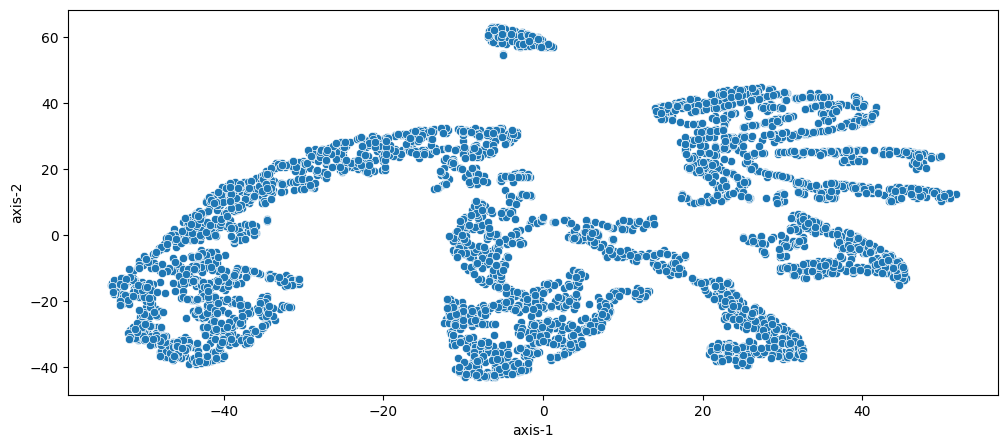

In [120]:
fig = plt.figure(figsize=(12, 5))
sns.scatterplot(data=rfm_table_processed, x='axis-1', y='axis-2');

Как и ожидалось от t-SNE, алгоритм сгруппировал наиболее похожие объекты в подобие кластеров, причём эти кластеры легко определить.

Теперь давайте воспользуемся алгоритмами кластеризации, чтобы сформировать новые сегменты клиентов.


### Задание 6.2
Попробуем воспользоваться методом k-means. 
Подберите оптимальное количество кластеров для метода k-means с помощью коэффициента силуэта, перебирая возможные значения от 3 до 8 включительно. 
В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.

1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.



Расчёт коэффициента силуэта для K-Means (t-SNE данные):
--------------------------------------------------
n_clusters=3: silhouette_score=0.3982
n_clusters=4: silhouette_score=0.4771
n_clusters=5: silhouette_score=0.4773
n_clusters=6: silhouette_score=0.4832
n_clusters=7: silhouette_score=0.4792
n_clusters=8: silhouette_score=0.4966
--------------------------------------------------

✅ ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ: 8
✅ МАКСИМАЛЬНЫЙ КОЭФФИЦИЕНТ СИЛУЭТА: 0.4966


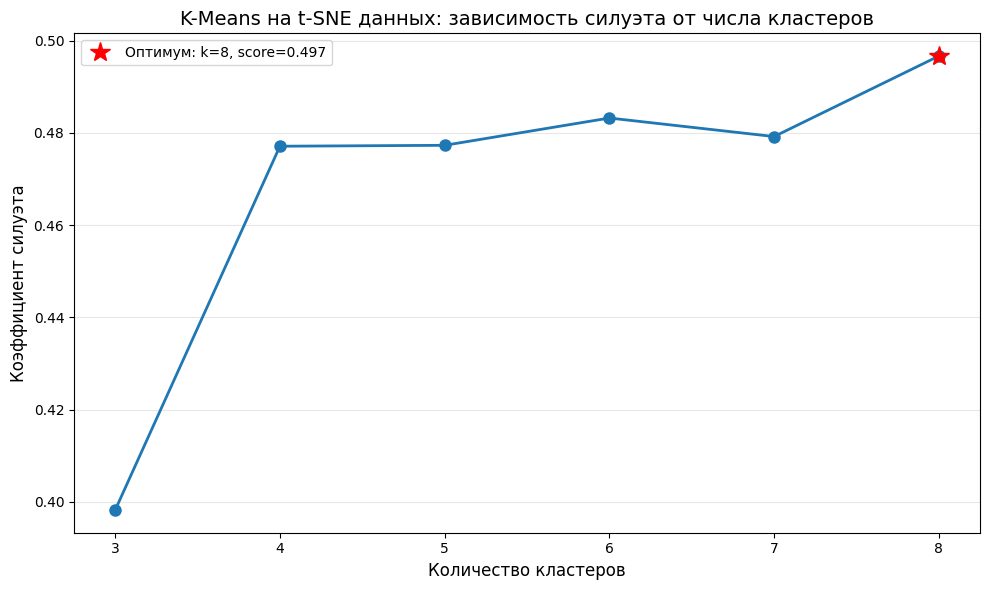

In [130]:

# Используем данные после t-SNE (уже сохранены в rfm_table_processed)
X_tsne = rfm_table_processed.values

# Перебираем количество кластеров от 3 до 8 (важно: именно 3-8, не 2-10!)
silhouette_scores = []
n_clusters_range = range(3, 9)

print("Расчёт коэффициента силуэта для K-Means (t-SNE данные):")
print("-" * 50)

for n_clusters in n_clusters_range:
    # Параметры по умолчанию, только random_state=42
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    
    # Обучаем модель и делаем предсказание
    labels = kmeans.fit_predict(X_tsne)
    
    # Вычисляем коэффициент силуэта
    silhouette_avg = silhouette_score(X_tsne, labels)
    silhouette_scores.append(silhouette_avg)
    
    print(f"n_clusters={n_clusters}: silhouette_score={silhouette_avg:.4f}")

# Находим оптимальное количество кластеров
best_idx = np.argmax(silhouette_scores)
best_n_clusters = n_clusters_range[best_idx]
max_silhouette_score = max(silhouette_scores)

print("-" * 50)
print(f"\n✅ ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ: {best_n_clusters}")
print(f"✅ МАКСИМАЛЬНЫЙ КОЭФФИЦИЕНТ СИЛУЭТА: {max_silhouette_score:.4f}")


# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.plot(n_clusters_range, silhouette_scores, marker='o', markersize=8, linewidth=2)
plt.plot(best_n_clusters, max_silhouette_score, 'r*', markersize=15, 
         label=f'Оптимум: k={best_n_clusters}, score={max_silhouette_score:.3f}')
plt.xlabel('Количество кластеров', fontsize=12)
plt.ylabel('Коэффициент силуэта', fontsize=12)
plt.title('K-Means на t-SNE данных: зависимость силуэта от числа кластеров', fontsize=14)
plt.xticks(n_clusters_range)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Задание 6.3
Попробуем воспользоваться EM-алгоритом. 

Подберите оптимальное количество кластеров для EM-алгоритма (GaussianMixture)  с помощью коэффициента силуэта, перебирая возможные значения от 3 до 8 включительно. 

В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.


1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.

Расчёт коэффициента силуэта для EM-алгоритма (t-SNE данные):
--------------------------------------------------
n_components=3: silhouette_score=0.3852
n_components=4: silhouette_score=0.4489
n_components=5: silhouette_score=0.3945
n_components=6: silhouette_score=0.4395
n_components=7: silhouette_score=0.4680
n_components=8: silhouette_score=0.4511
--------------------------------------------------

✅ ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ: 7
✅ МАКСИМАЛЬНЫЙ КОЭФФИЦИЕНТ СИЛУЭТА: 0.4680


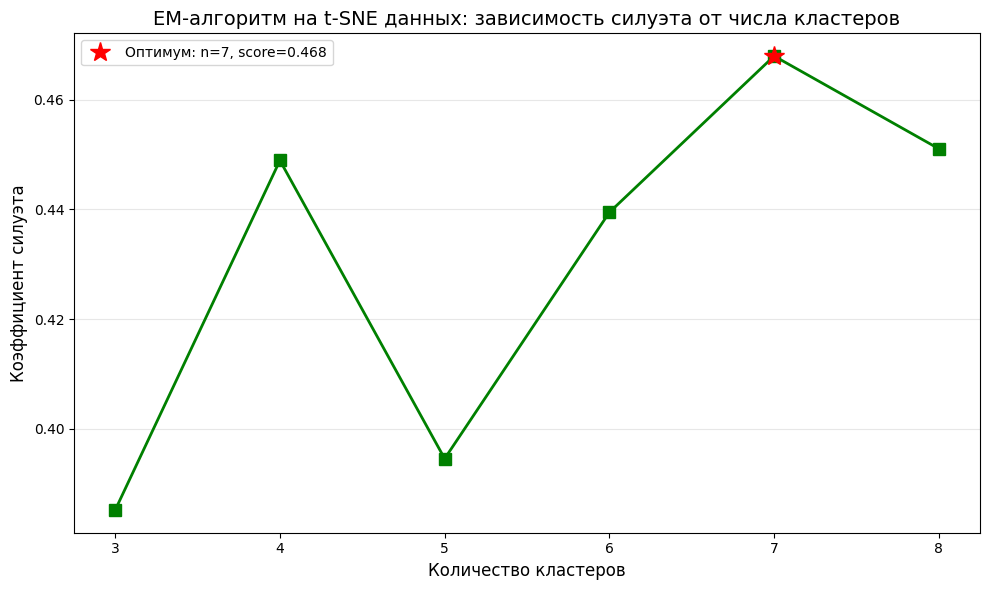

In [131]:

# Используем данные после t-SNE
X_tsne = rfm_table_processed.values

# Стандартизация данных (важно для EM-алгоритма!)
scaler = StandardScaler()
X_tsne_scaled = scaler.fit_transform(X_tsne)

# Перебираем количество кластеров от 3 до 8 включительно
silhouette_scores_em = []
n_components_range = range(3, 9)

print("Расчёт коэффициента силуэта для EM-алгоритма (t-SNE данные):")
print("-" * 50)

for n_components in n_components_range:
    # Параметры по умолчанию, только random_state=42
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    
    # Обучаем модель и делаем предсказание
    labels = gmm.fit_predict(X_tsne_scaled)
    
    # Вычисляем коэффициент силуэта
    silhouette_avg = silhouette_score(X_tsne_scaled, labels)
    silhouette_scores_em.append(silhouette_avg)
    
    print(f"n_components={n_components}: silhouette_score={silhouette_avg:.4f}")

# Находим оптимальное количество кластеров
best_idx = np.argmax(silhouette_scores_em)
best_n_components = n_components_range[best_idx]
max_silhouette_score_em = max(silhouette_scores_em)

print("-" * 50)
print(f"\n✅ ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ: {best_n_components}")
print(f"✅ МАКСИМАЛЬНЫЙ КОЭФФИЦИЕНТ СИЛУЭТА: {max_silhouette_score_em:.4f}")


# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, silhouette_scores_em, marker='s', markersize=8, 
         linewidth=2, color='green')
plt.plot(best_n_components, max_silhouette_score_em, 'r*', markersize=15, 
         label=f'Оптимум: n={best_n_components}, score={max_silhouette_score_em:.3f}')
plt.xlabel('Количество кластеров', fontsize=12)
plt.ylabel('Коэффициент силуэта', fontsize=12)
plt.title('EM-алгоритм на t-SNE данных: зависимость силуэта от числа кластеров', fontsize=14)
plt.xticks(n_components_range)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



### Задание 6.4
Наконец, попробуем воспользоваться алгоритмом алгомеративной кластеризации (AgglomerativeClustering).

Подберите оптимальное количество кластеров для алгоритма агломеративной кластеризации с помощью коэффициента силуэта, перебирая возможные значения от 2 до 8 включительно. 

Все параметры, за исключением числа кластеров, оставьте по умолчанию.


1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.



Расчёт коэффициента силуэта для AgglomerativeClustering (t-SNE данные):
--------------------------------------------------
n_clusters=2: silhouette_score=0.3827
n_clusters=3: silhouette_score=0.4268
n_clusters=4: silhouette_score=0.4444
n_clusters=5: silhouette_score=0.4596
n_clusters=6: silhouette_score=0.4554
n_clusters=7: silhouette_score=0.4678
n_clusters=8: silhouette_score=0.4906
--------------------------------------------------

✅ ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ: 8
✅ МАКСИМАЛЬНЫЙ КОЭФФИЦИЕНТ СИЛУЭТА: 0.4906


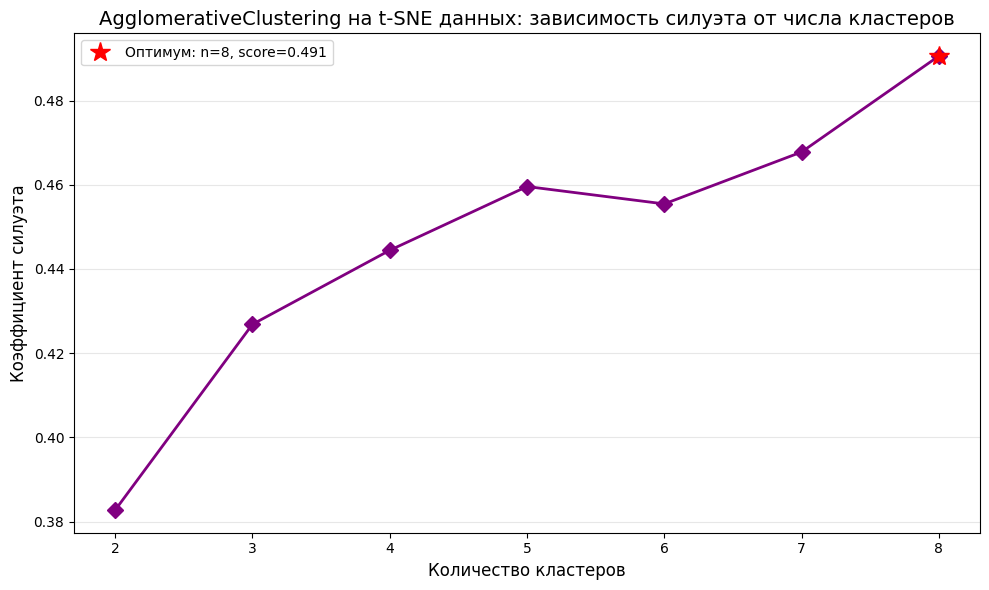

In [132]:
from sklearn.cluster import AgglomerativeClustering

# Используем данные после t-SNE
X_tsne = rfm_table_processed.values

# Перебираем количество кластеров от 2 до 8 включительно
silhouette_scores_agg = []
n_clusters_range = range(2, 9)

print("Расчёт коэффициента силуэта для AgglomerativeClustering (t-SNE данные):")
print("-" * 50)

for n_clusters in n_clusters_range:
    # Все параметры по умолчанию, только n_clusters меняем
    agg = AgglomerativeClustering(n_clusters=n_clusters)
    
    # Обучаем модель и делаем предсказание
    labels = agg.fit_predict(X_tsne)
    
    # Вычисляем коэффициент силуэта
    silhouette_avg = silhouette_score(X_tsne, labels)
    silhouette_scores_agg.append(silhouette_avg)
    
    print(f"n_clusters={n_clusters}: silhouette_score={silhouette_avg:.4f}")

# Находим оптимальное количество кластеров
best_idx = np.argmax(silhouette_scores_agg)
best_n_clusters = n_clusters_range[best_idx]
max_silhouette_score_agg = max(silhouette_scores_agg)

print("-" * 50)
print(f"\n✅ ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ: {best_n_clusters}")
print(f"✅ МАКСИМАЛЬНЫЙ КОЭФФИЦИЕНТ СИЛУЭТА: {max_silhouette_score_agg:.4f}")


# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.plot(n_clusters_range, silhouette_scores_agg, marker='D', markersize=8, 
         linewidth=2, color='purple')
plt.plot(best_n_clusters, max_silhouette_score_agg, 'r*', markersize=15, 
         label=f'Оптимум: n={best_n_clusters}, score={max_silhouette_score_agg:.3f}')
plt.xlabel('Количество кластеров', fontsize=12)
plt.ylabel('Коэффициент силуэта', fontsize=12)
plt.title('AgglomerativeClustering на t-SNE данных: зависимость силуэта от числа кластеров', fontsize=14)
plt.xticks(n_clusters_range)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Задание 6.5
Давайте посмотрим на распределение кластеров.

1) Сначала нужно определить лучшую модель. Для какой модели с оптимальным количеством кластеров коэффициент силуэта наибольший?
* K-Means
* GaussianMixture
* AgglomerativeClustering


2) Обучите лучшую модель с подобранным ранее количеством кластеров на декомпозированных данных. 
Сколько клиентов попало в самый большой кластер?



In [ ]:
# Обучаем K-means с оптимальным числом кластеров (n=8)
kmeans_best = KMeans(n_clusters=8, random_state=42)
labels = kmeans_best.fit_predict(rfm_table_processed.values)

# Считаем количество клиентов в каждом кластере
cluster_counts = np.bincount(labels)

print("Распределение клиентов по кластерам:")
for i, count in enumerate(cluster_counts):
    print(f"  Кластер {i}: {count} клиентов")

# Размер самого большого кластера
max_cluster_size = cluster_counts.max()
print(f"\nРазмер самого большого кластера: {max_cluster_size}")

Распределение клиентов по кластерам:
  Кластер 0: 114 клиентов
  Кластер 1: 678 клиентов
  Кластер 2: 338 клиентов
  Кластер 3: 914 клиентов
  Кластер 4: 527 клиентов
  Кластер 5: 627 клиентов
  Кластер 6: 431 клиентов
  Кластер 7: 415 клиентов

Размер самого большого кластера: 914


In [135]:
# определеим лучшую модель в переменную
model  = kmeans_best

Визуализируем результаты кластеризации:

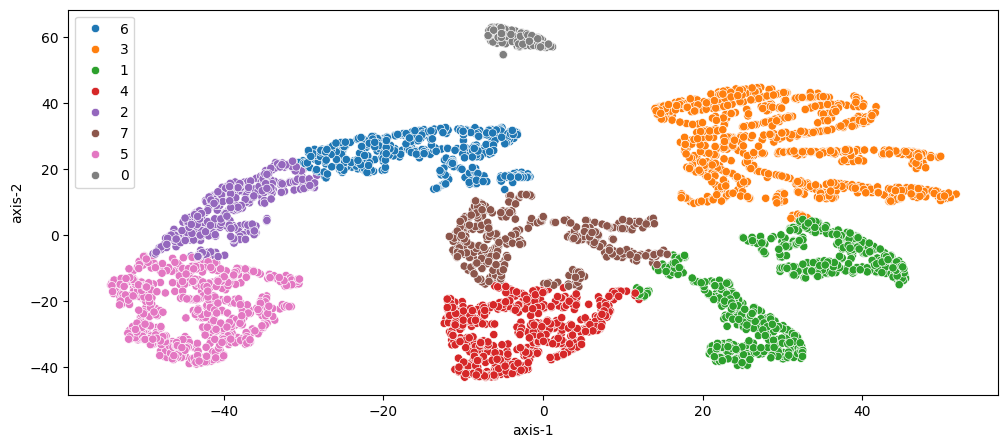

In [136]:
fig = plt.figure(figsize=(12, 5))
sns.scatterplot(data=rfm_table_processed, x='axis-1', y='axis-2', hue=model.labels_.astype('str'));


Итак, у нас есть 7 сегментов клиентов. Давайте попробуем составить профиль для этих сегментов. 


### Задание 6.6

Для составления профиля кластеров нам необходимо вернуться от декомпозированных данных к RFM-таблице (очищенной от выбросов).

Сгруппируйте RFM-таблицу по полученным кластерам и рассчитайте среднее по каждому из признаков. Для наглядности округлите все значения в столбцах до целого числа.

Чему равно максимальное среднее значение признака Recency в полученной таблице? Ответ округлите до целого числа.

In [152]:
import numpy as np
import pandas as pd

# Добавляем метки кластеров в RFM-таблицу (очищенную от выбросов)
# Используем метки из лучшей модели (K-means с n=8)
rfm_table = rfm_table.copy()
rfm_table['cluster'] = model.labels_

# Группируем по кластерам и считаем среднее по каждому признаку
cluster_profiles = rfm_table.groupby('cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Округляем все значения до целого числа (для наглядности)
cluster_profiles_rounded = cluster_profiles.round(0).astype(int)

print("Профили кластеров (средние значения, округлённые до целого):")
print(cluster_profiles_rounded)

print("\n" + "="*70)

# Находим максимальное среднее значение Recency
max_recency = cluster_profiles['Recency'].max()
max_recency_rounded = round(max_recency)

print(f"Максимальное среднее значение Recency: {max_recency:.2f}")
print(f"Округлённо до целого: {max_recency_rounded}")

# Дополнительная информация
print("\n" + "="*70)
print("ДЕТАЛЬНЫЙ АНАЛИЗ КЛАСТЕРОВ")
print("="*70)

for cluster_id in cluster_profiles.index:
    profile = cluster_profiles.loc[cluster_id]
    print(f"\nКластер {cluster_id}:")
    print(f"  Recency: {profile['Recency']:.0f} дней")
    print(f"  Frequency: {profile['Frequency']:.0f} заказов")
    print(f"  Monetary: {profile['Monetary']:.0f} фунтов")
    print(f"  Количество клиентов: {(rfm_table_cleaned['cluster'] == cluster_id).sum()}")

Профили кластеров (средние значения, округлённые до целого):
         Recency  Frequency  Monetary
cluster                              
0            365          1       234
1             40          3       993
2            157          1       271
3             32          7      2416
4             38          2       604
5             44          1       325
6            282          1       355
7            178          3       652

Максимальное среднее значение Recency: 365.46
Округлённо до целого: 365

ДЕТАЛЬНЫЙ АНАЛИЗ КЛАСТЕРОВ

Кластер 0:
  Recency: 365 дней
  Frequency: 1 заказов
  Monetary: 234 фунтов
  Количество клиентов: 114

Кластер 1:
  Recency: 40 дней
  Frequency: 3 заказов
  Monetary: 993 фунтов
  Количество клиентов: 678

Кластер 2:
  Recency: 157 дней
  Frequency: 1 заказов
  Monetary: 271 фунтов
  Количество клиентов: 338

Кластер 3:
  Recency: 32 дней
  Frequency: 7 заказов
  Monetary: 2416 фунтов
  Количество клиентов: 914

Кластер 4:
  Recency: 38 дней
  Freque

### Задание 6.7
Визуализируйте профили кластеров в виде полярной диаграммы на основе средних RFM-характеристик, вычисленных для каждого кластера.

Проанализируйте кластеры и на основе анализа сопоставьте номер кластера и его описание.

* Кластер соответствует «лояльным» клиентам, которые приносят наибольший доход, совершают покупки чаще всего, а давность их последней покупки наименьшая.
* Кластер соответствует «перспективным» клиентам, которые являются активными покупателями, но покупают не так часто и не так много, как лояльные клиенты.
* Кластер соответствует «подвисшим» клиентам, которые относительно недавно сделали несколько заказов на небольшие суммы. Потенциально эти клиенты могут быть переведены в кластер «перспективных».
* Кластер соответствует клиентам «в зоне риска», которые несколько раз покупали товары на небольшие суммы, однако их последняя покупка была совершена более пяти месяцев назад.
* Кластер соответствует клиентам-«новичкам», которые относительно недавно сделали один заказ на небольшую сумму. 
* Кластер соответствует «спящим» или «почти потерянным» клиентам, которые сделали один заказ на маленькую сумму более семи месяцев назад и больше не возвращались.
* Кластер соответствует «потерянным» клиентам, которые купили меньше всего товара, и их последняя покупка была совершена около года назад.



In [153]:
# Убеждаемся, что метки кластеров добавлены в таблицу
rfm_table['cluster'] = model.labels_

# Группируем по кластерам и считаем средние значения RFM-признаков
cluster_profiles = rfm_table.groupby('cluster')[['Recency', 'Frequency', 'Monetary']].mean()

print("Средние значения RFM по кластерам:")
print(cluster_profiles)

Средние значения RFM по кластерам:
            Recency  Frequency     Monetary
cluster                                    
0        365.456140   1.043860   233.802982
1         39.684366   3.455752   992.583083
2        157.275148   1.000000   270.928550
3         32.400438   6.769147  2416.252057
4         37.878558   1.979127   603.921954
5         44.157895   1.000000   324.641005
6        281.519722   1.092807   354.961160
7        178.086747   2.513253   651.883855


In [154]:
# Визуализируем профили кластеров (функция plot_cluster_profile определена ранее в ноутбуке)
plot_cluster_profile(cluster_profiles, n_clusters=8)

## 7. RFM-кластеризация клиентов: часть 3

Мы построили модель кластеризации для части клиентов.Но как сделать предсказание сегмента для клиентов, которые не попали в обучающую выборку?

Вы, вероятно, скажете: «Воспользоваться методом predict()!»

Верно, однако всё не так просто.

Вспомним, что мы обучали наши алгоритмы кластеризации на сжатом с помощью t-SNE пространстве признаков. То есть, чтобы сделать предсказание для новых объектов, не попавших в выборку, нам необходимо будет совершить трансформацию признаков этих объектов в новое сжатое пространство. 

Однако проблема t-SNE заключается в том, что алгоритм непараметрический. Это значит, что он, в отличие от таких алгоритмов, как PCA и SVD, не создаёт явной функции отображения. Проще говоря, алгоритм трансформирует пространство признаков для обучающей выборки, но не запоминает, каким образом это делает. Это значит, что, передав в алгоритм новые объекты для сжатия пространства, мы получим абсолютно новое представление пространства, не имеющее отношения к тому, что мы построили для обучающей выборки. То есть произойдёт искажение, что может привести к неверным результатам кластеризации.

Именно поэтому у класса TSNE из библиотеки sklearn нет такого метода, как transform(), у него есть только метод fit_transform() — заново обучить алгоритм t-SNE и произвести трансформацию.

Как же тогда производить кластеризацию для новых объектов, если мы не можем сжимать размерность для новых данных?

Давайте сведём задачу кластеризации к задаче классификации. Действительно, у нас теперь есть истинные метки кластеров, а есть клиенты, которые описываются RFM-характеристиками. Давайте обучим модель, которая на основе RFM-характеристик будет предсказывать клиентский сегмент. 

### Задание 7.1

Разделите исходные данные на тренировочную и тестовую выборки в соотношении 80/20. В качестве параметра random_state возьмите число 42.

Сколько клиентов попали в тестовую выборку?

In [155]:
from sklearn.model_selection import train_test_split

# Создаём матрицу наблюдений X и вектор правильных ответов y
X = rfm_table[['Recency', 'Frequency', 'Monetary']]  # очищенная RFM-таблица
y = labels  # метки кластеров, предсказанные ранее моделью K-means

# Разделяем данные в соотношении 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"Общее количество клиентов: {len(X)}")
print(f"Размер тренировочной выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")
print(f"\nСоотношение: {len(X_train)/len(X):.2%} / {len(X_test)/len(X):.2%}")

Общее количество клиентов: 4044
Размер тренировочной выборки: 3235
Размер тестовой выборки: 809

Соотношение: 80.00% / 20.00%


Дальше нам осталось только построить несколько моделей и выбрать из них лучшую. 
Мы знаем, что алгоритм t-SNE является нелинейным методом понижения размерности. Можно смело предположить, что линейные модели, такие как логистическая регрессия, в данной задаче нам мало чем помогут (можете убедиться в этом самостоятельно, обучив модель логистической регрессии на тренировочной выборке и оценив качество на тестовой).

Поэтому давайте сразу возьмём тяжелую артиллерию — ансамблевые алгоритмы. 


### Задание 7.2
Начнём со случайного леса. С помощью GridSearchCV организуйте перебор параметров случайного леса (RandomForestClassifier) на следующей сетке параметров:

```
param_grid = {
    'max_depth': range(5, 15),
    'criterion': ['gini', 'entropy'],
    'n_estimators': [100, 200, 500]
}
```
В качестве параметра random_state для модели случайного леса используйте число 42.
В качестве метрики используйте accuracy. Количество фолдов для кросс-валидации — 5.

1) Обучите GridSearchCV на тренировочной выборке. Чему равна оптимальная максимальная глубина деревьев в случайном лесу?

2) С помощью лучшей модели сделайте предсказание для тестовой выборки и рассчитайте метрику accuracy. Ответ округлите до трёх знаков после точки-разделителя.



In [156]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Задаём сетку параметров
param_grid = {
    'max_depth': range(5, 15),
    'criterion': ['gini', 'entropy'],
    'n_estimators': [100, 200, 500]
}

# Создаём модель случайного леса
rf = RandomForestClassifier(random_state=42)

# Создаём GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,  # используем все ядра процессора для ускорения
    verbose=1   # вывод прогресса
)

# Обучаем GridSearchCV на тренировочной выборке
print("Запуск GridSearchCV...")
grid_search.fit(X_train, y_train)

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ GRIDSEARCHCV")
print("="*70)

# 1. Оптимальная максимальная глубина деревьев
best_max_depth = grid_search.best_params_['max_depth']
print(f"1. Оптимальная максимальная глубина деревьев: {best_max_depth}")

# Полные лучшие параметры
print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший accuracy на кросс-валидации: {grid_search.best_score_:.4f}")

# 2. Предсказание на тестовой выборке и расчёт accuracy
y_pred = grid_search.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n2. Accuracy на тестовой выборке: {accuracy:.4f}")
print(f"   Округлённо до трёх знаков: {round(accuracy, 3)}")

Запуск GridSearchCV...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

РЕЗУЛЬТАТЫ GRIDSEARCHCV
1. Оптимальная максимальная глубина деревьев: 11

Лучшие параметры: {'criterion': 'gini', 'max_depth': 11, 'n_estimators': 100}
Лучший accuracy на кросс-валидации: 0.9895

2. Accuracy на тестовой выборке: 0.9876
   Округлённо до трёх знаков: 0.988


Итак, значение метрики accuracy очень высокое, но не идеальное. Давайте попробуем его улучшить, воспользовавшись бустингом.

### Задание 7.3
С помощью GridSearchCV организуйте перебор параметров градиентного бустинга (GradientBoostingClassifier) на следующей сетке параметров:
```
param_grid = {
    'max_depth': range(3, 7),
    'learning_rate': [0.001, 0.01, 0.1],
    'n_estimators': [100, 200, 500]
}
```

В качестве параметра random_state для модели градиентного бустинга используйте число 42.
В качестве метрики используйте accuracy. Количество фолдов для кросс-валидации — 5. 

1) Обучите GridSearchCV на тренировочной выборке. Чему равна оптимальная максимальная глубина деревьев в градиентном бустинге?
Ответ: 6
2) С помощью лучшей модели сделайте предсказание для тестовой выборки и рассчитайте метрику accuracy. Ответ округлите до трёх знаков после точки-разделителя.



In [157]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV


# Задаём сетку параметров
param_grid = {
    'max_depth': range(3, 7),
    'learning_rate': [0.001, 0.01, 0.1],
    'n_estimators': [100, 200, 500]
}

# Создаём модель градиентного бустинга
gb = GradientBoostingClassifier(random_state=42)

# Создаём GridSearchCV
grid_search_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Обучаем GridSearchCV на тренировочной выборке
print("Запуск GridSearchCV для GradientBoostingClassifier...")
print("⚠️  Внимание: обучение может занять несколько минут!")
grid_search_gb.fit(X_train, y_train)

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ GRIDSEARCHCV (GradientBoosting)")
print("="*70)

# 1. Оптимальная максимальная глубина деревьев
best_max_depth_gb = grid_search_gb.best_params_['max_depth']
print(f"1. Оптимальная максимальная глубина деревьев: {best_max_depth_gb}")

# Полные лучшие параметры
print(f"\nЛучшие параметры: {grid_search_gb.best_params_}")
print(f"Лучший accuracy на кросс-валидации: {grid_search_gb.best_score_:.4f}")

# 2. Предсказание на тестовой выборке и расчёт accuracy
y_pred_gb = grid_search_gb.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print(f"\n2. Accuracy на тестовой выборке: {accuracy_gb:.4f}")
print(f"   Округлённо до трёх знаков: {round(accuracy_gb, 3)}")

Запуск GridSearchCV для GradientBoostingClassifier...
⚠️  Внимание: обучение может занять несколько минут!
Fitting 5 folds for each of 36 candidates, totalling 180 fits

РЕЗУЛЬТАТЫ GRIDSEARCHCV (GradientBoosting)
1. Оптимальная максимальная глубина деревьев: 4

Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
Лучший accuracy на кросс-валидации: 0.9873

2. Accuracy на тестовой выборке: 0.9827
   Округлённо до трёх знаков: 0.983


Отлично, мы справились с проблемой непараметричности t-SNE и смогли перейти от решения задачи кластеризации к задаче классификации. Теперь у нас есть модель, которая на основе RFM-характерик клиента автоматически определяет его сегмент.

**Что ещё можно сделать?**

Выделить оптовиков в отдельный сегмент. В таком случае идея метода RFM расширяется путём добавления в датасет информации о среднем количестве покупаемого товара за один заказ. То есть аббревиатура RFM превращается в RFMQ, где Q — среднее количество товаров в одном заказе.
Произвести кластерный анализ товаров на основе их описания и сформировать категории, по которым совершаются покупки.
Рассчитать частоту покупки каждой категории товаров для каждого клиента. Эта информация может стать основой для построения модели кластеризации и сегментирования клиентов по их интересам.
Наконец, воспользоваться информацией о сезонности покупок и добавить в модель информацию о частоте покупок клиентов в каждый из месяцев. Так можно определить, какие клиенты являются постоянными, то есть их покупки не зависят от сезона, а какие покупают товары только в преддверии праздников. Эта информация позволит экспериментировать с маркетинговой кампанией и повышать лояльность клиентов.

**1. 📦 Расширение RFM до RFMQ (выделение оптовиков)**

Самая простая и полезная модификация — добавление признака Q (Quantity), который поможет отделить розничных покупателей от оптовиков.

In [159]:
# Вычисляем среднее количество товаров в одном заказе для каждого клиента
avg_quantity_per_order = data.groupby('CustomerID').agg({
    'Quantity': 'mean',        # среднее количество за заказ
    'InvoiceNo': 'nunique'     # для контроля
}).rename(columns={'Quantity': 'AvgQuantity'})

# Объединяем с RFM-таблицей
rfmq_table = rfm_table.merge(
    avg_quantity_per_order, 
    on='CustomerID', 
    how='left'
)

print("RFMQ-таблица (первые 10 строк):")
print(rfmq_table.head(10))

# Статистика по новому признаку
print("\nСтатистика по AvgQuantity:")
print(rfmq_table['AvgQuantity'].describe())

# Выделяем оптовиков (например, тех, кто покупает в среднем > 20 товаров за заказ)
wholesale_threshold = rfmq_table['AvgQuantity'].quantile(0.95)
rfmq_table['is_wholesale'] = (rfmq_table['AvgQuantity'] > wholesale_threshold).astype(int)

print(f"\nПорог оптовиков (95-й перцентиль): {wholesale_threshold:.1f}")
print(f"Количество оптовиков: {rfmq_table['is_wholesale'].sum()}")
print(f"Доля оптовиков: {rfmq_table['is_wholesale'].mean():.2%}")

RFMQ-таблица (первые 10 строк):
  CustomerID  Recency  Frequency  Monetary  cluster   AvgQuantity  InvoiceNo
0      12346      325          1      0.00        6  74215.000000          1
1      12347        2          7   4310.00        3     13.505495          7
2      12348       75          4   1437.24        1     86.370370          4
3      12349       18          1   1457.55        4      8.750000          1
4      12350      310          1    294.40        6     12.250000          1
5      12352       36          7   1265.41        3      6.831169          7
6      12353      204          1     89.00        2      5.000000          1
7      12354      232          1   1079.40        6      9.137931          1
8      12355      214          1    459.40        2     18.461538          1
9      12356       22          3   2487.43        3     27.120690          3

Статистика по AvgQuantity:
count     4044.000000
mean        45.424327
std       1246.986122
min          1.000000
25%  

**2. 📅 Сезонный анализ клиентов**

Определим, какие клиенты покупают весь год, а какие — только в пиковые сезоны.

Всего месяцев в данных: 12

Распределение клиентов по количеству активных месяцев:
ActiveMonths
1     1644
2      921
3      526
4      388
5      265
6      165
7      101
8       91
9       72
10      54
11      49
12      58
Name: count, dtype: int64

Распределение по типам сезонности:
SeasonalityType
Разовый           2565
Сезонный          1179
Регулярный         429
Круглогодичный     161
Name: count, dtype: int64


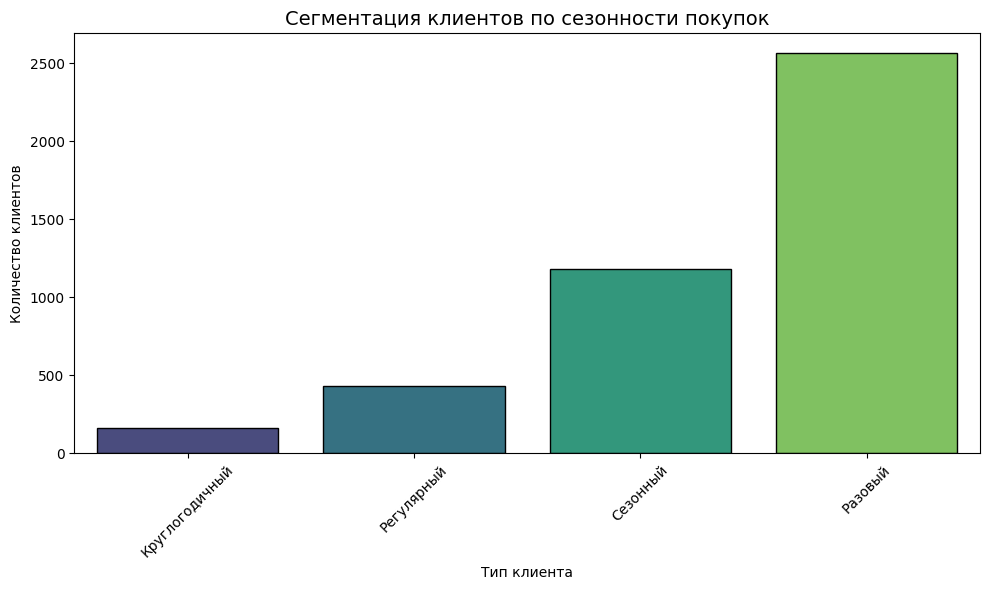

In [160]:
# Для каждого клиента считаем количество активных месяцев
months_active = data.groupby('CustomerID')['Month'].nunique().reset_index()
months_active.columns = ['CustomerID', 'ActiveMonths']

# Доля активных месяцев от общего числа месяцев в данных
total_months = data['Month'].nunique()
months_active['ActivityRatio'] = months_active['ActiveMonths'] / total_months

print(f"Всего месяцев в данных: {total_months}")
print("\nРаспределение клиентов по количеству активных месяцев:")
print(months_active['ActiveMonths'].value_counts().sort_index())

# Сегментация по сезонности
def classify_seasonality(row):
    if row['ActiveMonths'] >= 10:
        return 'Круглогодичный'
    elif row['ActiveMonths'] >= 6:
        return 'Регулярный'
    elif row['ActiveMonths'] >= 3:
        return 'Сезонный'
    else:
        return 'Разовый'

months_active['SeasonalityType'] = months_active.apply(classify_seasonality, axis=1)

print("\nРаспределение по типам сезонности:")
print(months_active['SeasonalityType'].value_counts())

# Визуализация
plt.figure(figsize=(10, 6))
sns.countplot(data=months_active, x='SeasonalityType', 
              order=['Круглогодичный', 'Регулярный', 'Сезонный', 'Разовый'],
              palette='viridis')
plt.title('Сегментация клиентов по сезонности покупок', fontsize=14)
plt.xlabel('Тип клиента')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**3. 🏷️ Кластеризация товаров по описанию (NLP)**

Это более сложная задача, требующая обработки естественного языка, поэтому ограничемся выделением тегов из описания

In [161]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Предобработка описаний товаров
def preprocess_description(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

# Уникальные товары с описаниями
products = data[['StockCode', 'Description']].drop_duplicates().dropna()
products['clean_desc'] = products['Description'].apply(preprocess_description)

# TF-IDF векторизация
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(products['clean_desc'])

# Кластеризация товаров
n_product_clusters = 10
kmeans_products = KMeans(n_clusters=n_product_clusters, random_state=42)
products['category'] = kmeans_products.fit_predict(tfidf_matrix)

# Анализ топ-слов в каждом кластере
def get_top_words(cluster_id, vectorizer, kmeans, n_words=10):
    center = kmeans.cluster_centers_[cluster_id]
    feature_names = vectorizer.get_feature_names_out()
    top_indices = center.argsort()[-n_words:][::-1]
    return [feature_names[i] for i in top_indices]

print("Топ-слова в каждом продуктовом кластере:")
for i in range(n_product_clusters):
    top_words = get_top_words(i, vectorizer, kmeans_products)
    print(f"  Категория {i}: {', '.join(top_words)}")

Топ-слова в каждом продуктовом кластере:
  Категория 0: dinosaur, toast, set, sticker, best, piece, watering, assorted, jigsaw, doilies
  Категория 1: pink, polkadot, flower, heart, flock, cover, butterfly, cushion, bag, charm
  Категория 2: christmas, decoration, tree, heart, hanging, star, cm, set, zinc, bell
  Категория 3: drawer, acrylic, knob, ceramic, jewel, edwardian, crackle, faceted, bangle, red
  Категория 4: rose, english, candle, set, danish, box, gingham, vintage, sud, du
  Категория 5: vintage, christmas, bag, set, doily, leaf, red, tin, font, number
  Категория 6: holder, tlight, hanging, heart, glass, zinc, silver, candle, star, bird
  Категория 7: blue, polkadot, french, sign, metal, door, flower, paisley, garden, egg
  Категория 8: set, red, design, box, heart, bag, glass, retrospot, necklace, wall
  Категория 9: small, frame, photo, heart, bowl, glass, pink, landmark, silver, record


**4. 📊 Итоговый расширенный профиль клиента**

In [163]:
# Вычисляем среднее количество товаров в одном заказе для каждого клиента
avg_quantity_per_order = data.groupby('CustomerID')['Quantity'].mean().reset_index()
avg_quantity_per_order.columns = ['CustomerID', 'AvgQuantity']

# Для каждого клиента считаем количество активных месяцев
months_active = data.groupby('CustomerID')['Month'].nunique().reset_index()
months_active.columns = ['CustomerID', 'ActiveMonths']

# Доля активных месяцев от общего числа месяцев в данных
total_months = data['Month'].nunique()
months_active['ActivityRatio'] = months_active['ActiveMonths'] / total_months

# Сегментация по сезонности
def classify_seasonality(row):
    if row['ActiveMonths'] >= 10:
        return 'Круглогодичный'
    elif row['ActiveMonths'] >= 6:
        return 'Регулярный'
    elif row['ActiveMonths'] >= 3:
        return 'Сезонный'
    else:
        return 'Разовый'

months_active['SeasonalityType'] = months_active.apply(classify_seasonality, axis=1)

# Проверяем, что CustomerID есть во всех таблицах
print("Столбцы rfm_table:", rfm_table.columns.tolist())
print("Столбцы avg_quantity_per_order:", avg_quantity_per_order.columns.tolist())
print("Столбцы months_active:", months_active.columns.tolist())

# Объединяем всё в единую таблицу
customer_profile = rfm_table.copy()

# Добавляем Q (среднее количество)
customer_profile = customer_profile.merge(
    avg_quantity_per_order[['CustomerID', 'AvgQuantity']], 
    on='CustomerID',
    how='left'
)

# Добавляем сезонность
customer_profile = customer_profile.merge(
    months_active[['CustomerID', 'ActiveMonths', 'ActivityRatio', 'SeasonalityType']], 
    on='CustomerID',
    how='left'
)

print("\nРасширенный профиль клиента (первые 10 строк):")
print(customer_profile.head(10))

print(f"\nВсего признаков: {len(customer_profile.columns)}")
print(f"Всего клиентов: {len(customer_profile)}")

Столбцы rfm_table: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'cluster']
Столбцы avg_quantity_per_order: ['CustomerID', 'AvgQuantity']
Столбцы months_active: ['CustomerID', 'ActiveMonths', 'ActivityRatio', 'SeasonalityType']

Расширенный профиль клиента (первые 10 строк):
  CustomerID  Recency  Frequency  Monetary  cluster   AvgQuantity  \
0      12346      325          1      0.00        6  74215.000000   
1      12347        2          7   4310.00        3     13.505495   
2      12348       75          4   1437.24        1     86.370370   
3      12349       18          1   1457.55        4      8.750000   
4      12350      310          1    294.40        6     12.250000   
5      12352       36          7   1265.41        3      6.831169   
6      12353      204          1     89.00        2      5.000000   
7      12354      232          1   1079.40        6      9.137931   
8      12355      214          1    459.40        2     18.461538   
9      12356       22        